## Basis Anlaysis During March 2023 USDC Depeg

**Author:** Yield Curve Surfers  
**Date:** February 2026

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE_PATH = Path("/content/drive/MyDrive/Yield Curve Surfers")
DATA_PATH = BASE_PATH / "Data"
CODE_PATH = BASE_PATH / "Code"

# Exchange cleaned folders
BINANCE_PATH   = DATA_PATH / "Binance"
COINBASE_PATH  = DATA_PATH / "Coinbase" / "cleaned"
KRAKEN_PATH    = DATA_PATH / "Kraken" / "cleaned"
CRYPTOCOM_PATH = DATA_PATH / "Crypto.com" / "cleaned"

EXCHANGE_PATHS = {
    "Binance": BINANCE_PATH,
    "Coinbase": COINBASE_PATH,
    "Kraken": KRAKEN_PATH,
    "Crypto.com": CRYPTOCOM_PATH
}

print(f"Base path: {BASE_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Code path: {CODE_PATH}")

# Verify structure
for name, path in EXCHANGE_PATHS.items():
    if path.exists():
        print(f"✓ {name}: {len(list(path.glob('*.csv')))} CSV files")
    else:
        print(f"✗ {name}: NOT FOUND")

Base path: /content/drive/MyDrive/Yield Curve Surfers
Data path: /content/drive/MyDrive/Yield Curve Surfers/Data
Code path: /content/drive/MyDrive/Yield Curve Surfers/Code
✓ Binance: 5 CSV files
✓ Coinbase: 5 CSV files
✓ Kraken: 6 CSV files
✓ Crypto.com: 4 CSV files


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import os
import statsmodels.api as sm
import random
from scipy.stats import ks_2samp
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
SVB_WINDOW = ("2023-03-01", "2023-03-21")


def _svb_bounds():
    s = pd.Timestamp(SVB_WINDOW[0], tz="UTC")
    e = pd.Timestamp(SVB_WINDOW[1], tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    return s, e

def parse_timestamp(df: pd.DataFrame) -> pd.Series:
    """
    Standardizes timestamps across various exchange schemas.
    Prioritizes numeric unix timestamps to avoid string parsing errors.
    """

    if "timestamp" in df.columns:
        return pd.to_datetime(df["timestamp"], unit="ms", utc=True, errors="coerce")

    if "open_time_ms" in df.columns:
        return pd.to_datetime(df["open_time_ms"], unit="ms", utc=True, errors="coerce")

    if "start" in df.columns:
        if df["start"].iloc[0] > 1e11:
            return pd.to_datetime(df["start"], unit="ms", utc=True, errors="coerce")
        return pd.to_datetime(df["start"], unit="s", utc=True, errors="coerce")

    if "time_period_start" in df.columns:
        return pd.to_datetime(df["time_period_start"], utc=True, errors="coerce")

    if "timestamp_utc" in df.columns:
        return pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")

    if "open_time_utc" in df.columns:
        return pd.to_datetime(df["open_time_utc"], utc=True, errors="coerce")

    if "datetime" in df.columns:
        return pd.to_datetime(df["datetime"], utc=True, errors="coerce")

    raise ValueError("Unknown timestamp format. Check if columns match expected schema.")


def standardize_schema(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        # Kraken CoinAPI
        "price_open": "open",
        "price_high": "high",
        "price_low": "low",
        "price_close": "close",
        "volume_traded": "volume",
        "trades_count": "num_trades",

        # Kraken classic
        "trades": "num_trades",

        # Coinbase USDC
        "start": "start",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    for col in ["open", "high", "low", "close", "volume", "num_trades"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "num_trades" not in df.columns:
        df["num_trades"] = np.nan

    return df


def load_one_csv(fp: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(fp)
        df["timestamp"] = parse_timestamp(df)
        df = df.dropna(subset=["timestamp"])
        df = df.set_index("timestamp").sort_index()
        df = standardize_schema(df)

        s, e = _svb_bounds()
        df = df.loc[(df.index >= s) & (df.index <= e)]

        if df.empty:
            return pd.DataFrame()

        required = ["open", "high", "low", "close", "volume"]
        df = df.dropna(subset=required)
        df = df[~df.index.duplicated(keep="first")]

        return df

    except Exception as ex:
        print(f"Error loading {fp.name}: {ex}")
        return pd.DataFrame()


In [ ]:
print("="*80)
print("LOADING ALL OHLCV DATA")
print("="*80)

all_data = {}

def extract_pair(stem: str):
    match = re.search(r"_([A-Z]{6,10})_1m_", stem)
    if match:
        return match.group(1)
    return None

def load_exchange_data(exchange_name, path):
    print(f"\n{exchange_name.upper()}:")

    for filepath in sorted(path.glob("*.csv")):
        pair = extract_pair(filepath.stem)

        if pair is None:
            continue

        df = load_one_csv(filepath)

        if not df.empty:
            key = f"{exchange_name}_{pair}"
            all_data[key] = df

            print(
                f"  {pair:15s}: {len(df):,} rows | "
                f"{df.index.min().date()} to {df.index.max().date()}"
            )

# Load exchanges
load_exchange_data("binance", BINANCE_PATH)
load_exchange_data("coinbase", COINBASE_PATH)
load_exchange_data("cryptocom", CRYPTOCOM_PATH)
load_exchange_data("kraken", KRAKEN_PATH)

print(f"\n✓ Loaded {len(all_data)} datasets total")


LOADING ALL OHLCV DATA

BINANCE:
  BTCUSDC        : 30,240 rows | 2023-03-01 to 2023-03-21
  BTCUSDT        : 30,240 rows | 2023-03-01 to 2023-03-21
  BTCUSD         : 30,240 rows | 2023-03-01 to 2023-03-21
  USDCUSD        : 30,240 rows | 2023-03-01 to 2023-03-21
  USDTUSD        : 30,240 rows | 2023-03-01 to 2023-03-21

COINBASE:
  BTCUSDC        : 28,524 rows | 2023-03-01 to 2023-03-21
  BTCUSDT        : 28,519 rows | 2023-03-01 to 2023-03-21
  BTCUSD         : 29,963 rows | 2023-03-01 to 2023-03-21
  USDTUSDC       : 27,735 rows | 2023-03-01 to 2023-03-21

CRYPTOCOM:
  BTCUSDC        : 30,240 rows | 2023-03-01 to 2023-03-21
  BTCUSDT        : 30,240 rows | 2023-03-01 to 2023-03-21
  BTCUSD         : 30,240 rows | 2023-03-01 to 2023-03-21
  USDTUSDC       : 30,240 rows | 2023-03-01 to 2023-03-21

KRAKEN:
  BTCUSDC        : 30,175 rows | 2023-03-01 to 2023-03-21
  BTCUSDT        : 30,239 rows | 2023-03-01 to 2023-03-21
  BTCUSD         : 30,240 rows | 2023-03-01 to 2023-03-21
  USDCU

# CRO

In [ ]:
data_dir = "/content/drive/MyDrive/Yield Curve Surfers/Data"
if os.path.exists(data_dir):
    print("Found Data folder! Contents:", os.listdir(data_dir))
else:
    print("Data folder NOT FOUND. Check the path name.")

Found Data folder! Contents: ['Binance', 'Crypto.com', 'Coinbase', 'Kraken', 'Volumes', 'Tick Data', 'Cleaned', 'Liquidity', 'Order Book Data 05 02 25 2pm - 8pm', 'orderbook (March 2023)', 'Reserves', 'Currency Exchange Rates', 'MERGED DATASET', '2023_2025_data', 'Treasury holders.xlsx', 'data_gap_summary.csv', 'crypto_historical_data_daily_9 30 2022_2 23 2026.csv', 'Khush Data', 'T-bill holdings.xlsx', 'Large country dataset_values.xlsx', 'Bloomberg data']


In [ ]:
import pandas as pd

rows = []

for key, df in all_data.items():
    parts = key.split('_')
    exchange = parts[0]
    pair = parts[1]

    total_minutes = len(df)

    if total_minutes > 0:
        zero_n = (df['volume'].fillna(0) == 0).sum()

        rows.append({
            "exchange": exchange,
            "pair": pair,
            "zero_volume_minutes": int(zero_n),
            "total_minutes": int(total_minutes),
            "pct_zero_volume": 100.0 * zero_n / total_minutes
        })

# Create the summary DataFrame
summary_df = (
    pd.DataFrame(rows)
    .sort_values(["pct_zero_volume", "exchange"], ascending=[False, True])
    .reset_index(drop=True)
)

print("=== ZERO VOLUME ANALYSIS (SVB WINDOW) ===")
display(summary_df)

expected_min = 21 * 24 * 60
print(f"\nExpected minutes for 21 full days: {expected_min}")

=== ZERO VOLUME ANALYSIS (SVB WINDOW) ===


,exchange,pair,zero_volume_minutes,total_minutes,pct_zero_volume
0,cryptocom,BTCUSDC,30240,30240,100.000000
1,cryptocom,USDTUSDC,30240,30240,100.000000
2,coinbase,USDTUSDC,19642,27735,70.820263
3,binance,USDCUSD,19777,30240,65.400132
4,kraken,BTCUSDC,14467,30175,47.943662
5,binance,BTCUSDC,12971,30240,42.893519
6,kraken,BTCUSDT,9796,30239,32.395251
7,kraken,USDCUSD,9301,30203,30.794954
8,binance,USDTUSD,6033,30240,19.950397
9,coinbase,BTCUSDT,5170,28519,18.128265



Expected minutes for 21 full days: 30240


Let $P_t^{X,Q}$ denote the midprice of asset $X \in \{\text{BTC}, \text{ETH}\}$ quoted in currency  $Q \in \{\text{USD}, \text{USDT}\}$ at minute $t$ on the Crypto.com exchange. For each asset, we define the relative cross-quote basis between USD- and USDT-quoted markets as
$$
\text{Basis}_t^{X}=
\frac{P_t^{X,\mathrm{USD}} - P_t^{X,\mathrm{USDT}}}{P_t^{X,\mathrm{USDT}}}.
$$
This normalization yields a dimensionless measure of price dislocation that is comparable across assets and over time.
Positive values of $\text{Basis}_t^{X}$ indicate that the USD-quoted market trades at a premium relative to
the USDT-quoted market, while negative values indicate a discount.
The standardized series $Z_t^{X}$ measures the magnitude of each deviation in units of historical standard
deviations and is used solely as a diagnostic tool to compare the timing and intensity of basis dislocations
across assets, rather than for economic magnitude.


In [ ]:
print("Datasets currently loaded in 'all_data':")
for key in all_data.keys():
    print(f" -> {key}")

Datasets currently loaded in 'all_data':
 -> binance_BTCUSDC
 -> binance_BTCUSDT
 -> binance_BTCUSD
 -> binance_USDCUSD
 -> binance_USDTUSD
 -> coinbase_BTCUSDC
 -> coinbase_BTCUSDT
 -> coinbase_BTCUSD
 -> coinbase_USDTUSDC
 -> cryptocom_BTCUSDC
 -> cryptocom_BTCUSDT
 -> cryptocom_BTCUSD
 -> cryptocom_USDTUSDC
 -> kraken_BTCUSDC
 -> kraken_BTCUSDT
 -> kraken_BTCUSD
 -> kraken_USDCUSD
 -> kraken_USDTUSD


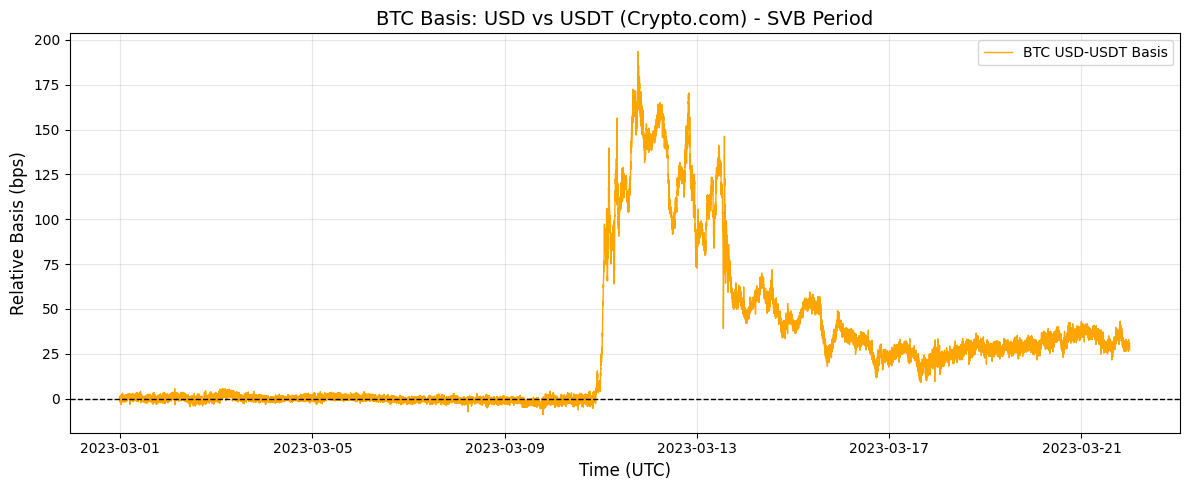

In [ ]:
btc_usd_df = all_data.get('cryptocom_BTCUSD')
btc_usdt_df = all_data.get('cryptocom_BTCUSDT')


if btc_usd_df is not None and btc_usdt_df is not None:

    # 3. Create a combined DataFrame for calculation
    df_plot = pd.DataFrame(index=btc_usd_df.index)
    df_plot['USD_price'] = btc_usd_df['close']
    df_plot['USDT_price'] = btc_usdt_df['close']
    df_plot = df_plot.dropna()

    # 4. Calculate BTC Basis in Basis Points (bps)
    # (Price USD - Price USDT) / Price USDT * 10,000
    df_plot["basis_bps"] = ((df_plot["USD_price"] - df_plot["USDT_price"]) / df_plot["USDT_price"]) * 10000

    # 5. Plot
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot.index, df_plot["basis_bps"], label="BTC USD-USDT Basis", color='orange', lw=1)

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title("BTC Basis: USD vs USDT (Crypto.com) - SVB Period", fontsize=14)
    plt.ylabel("Relative Basis (bps)", fontsize=12)
    plt.xlabel("Time (UTC)", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Error: BTC keys not found in 'all_data'.")
    print(f"Available keys: {list(all_data.keys())}")

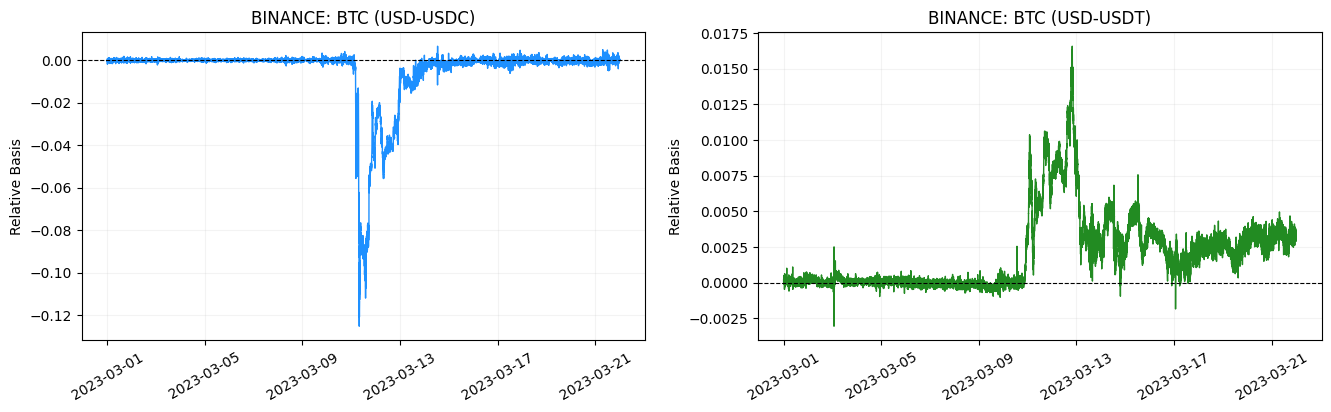

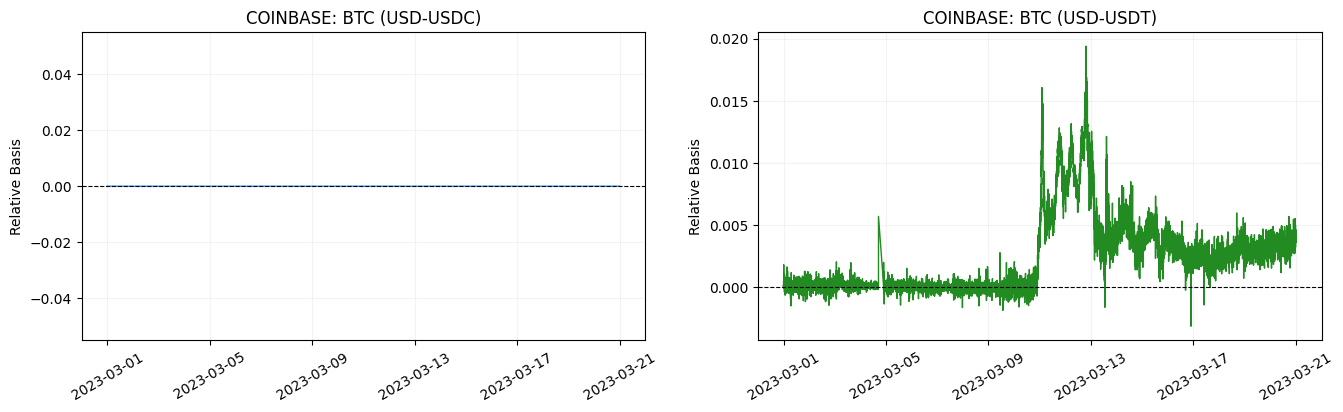

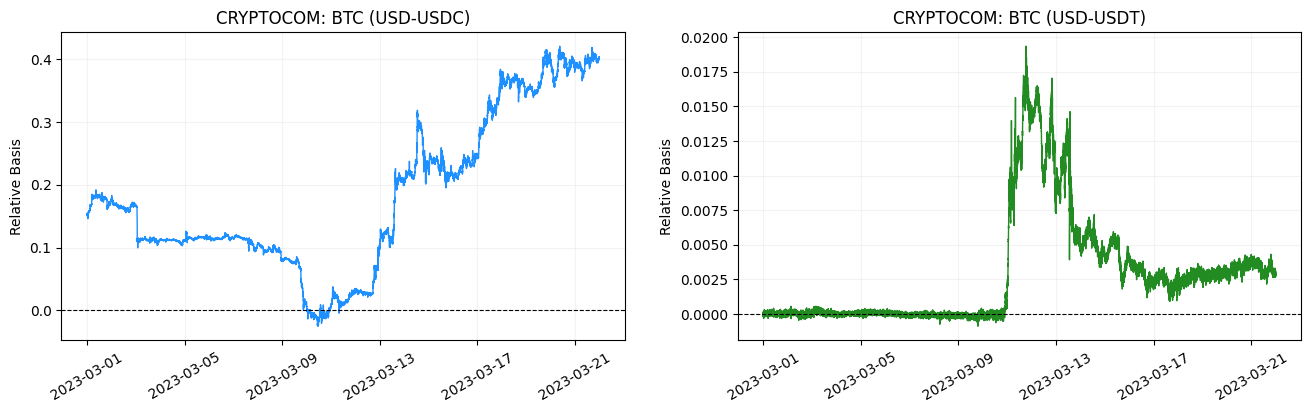

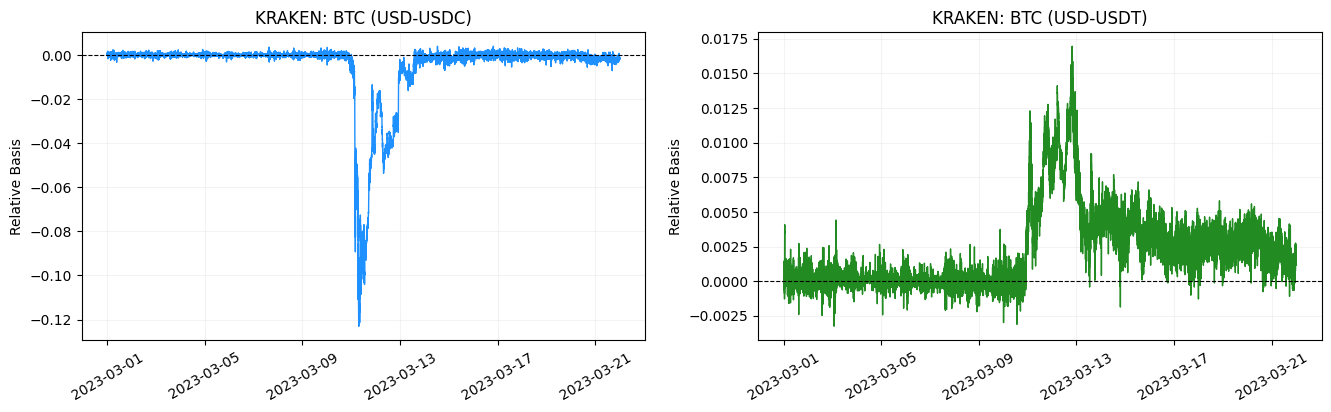

In [ ]:
import matplotlib.pyplot as plt

# 1. Identify unique exchanges from your data
exchanges = sorted(list(set(key.split('_')[0] for key in all_data.keys())))

asset = "BTC"

for exchange in exchanges:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    usd_k  = f"{exchange}_{asset}USD"
    usdc_k = f"{exchange}_{asset}USDC"
    usdt_k = f"{exchange}_{asset}USDT"

    # --- Plot 1: USD vs USDC ---
    if usd_k in all_data and usdc_k in all_data:
        p_usd = all_data[usd_k]['close']
        p_usdc = all_data[usdc_k]['close']
        df_usdc = pd.concat([p_usd, p_usdc], axis=1).dropna()
        basis_usdc = (df_usdc.iloc[:,0] - df_usdc.iloc[:,1]) / df_usdc.iloc[:,1]

        ax1.plot(basis_usdc.index, basis_usdc, color='dodgerblue', lw=1)
        ax1.set_title(f"{exchange.upper()}: {asset} (USD-USDC)")
    else:
        ax1.text(0.5, 0.5, 'USD/USDC Pairs Missing', ha='center', color='gray')

    # --- Plot 2: USD vs USDT ---
    if usd_k in all_data and usdt_k in all_data:
        p_usd = all_data[usd_k]['close']
        p_usdt = all_data[usdt_k]['close']
        df_usdt = pd.concat([p_usd, p_usdt], axis=1).dropna()
        basis_usdt = (df_usdt.iloc[:,0] - df_usdt.iloc[:,1]) / df_usdt.iloc[:,1]

        ax2.plot(basis_usdt.index, basis_usdt, color='forestgreen', lw=1)
        ax2.set_title(f"{exchange.upper()}: {asset} (USD-USDT)")
    else:
        ax2.text(0.5, 0.5, 'USD/USDT Pairs Missing', ha='center', color='gray')

    # Common formatting
    for ax in [ax1, ax2]:
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_ylabel("Relative Basis")
        ax.grid(True, alpha=0.15)
        # Rotates dates for better readability
        plt.setp(ax.get_xticklabels(), rotation=30)

    plt.show() # Forces the display of this exchange before moving to the next

In [ ]:
exchanges = sorted(list(set(key.split('_')[0] for key in all_data.keys())))
asset = "BTC"
basis_collection = {}

for exch in exchanges:
    usd_k  = f"{exch}_{asset}USD"
    usdc_k = f"{exch}_{asset}USDC"
    usdt_k = f"{exch}_{asset}USDT"

    # --- Calculate USD-USDC Basis ---
    if usd_k in all_data and usdc_k in all_data:
        p_usd = all_data[usd_k]['close']
        p_usdc = all_data[usdc_k]['close']
        df_tmp = pd.concat([p_usd, p_usdc], axis=1).dropna()
        # Formula: (USD - USDC) / USDC
        basis_collection[f"{exch}_USD_USDC"] = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]

    # --- Calculate USD-USDT Basis ---
    if usd_k in all_data and usdt_k in all_data:
        p_usd = all_data[usd_k]['close']
        p_usdt = all_data[usdt_k]['close']
        df_tmp = pd.concat([p_usd, p_usdt], axis=1).dropna()
        # Formula: (USD - USDT) / USDT
        basis_collection[f"{exch}_USD_USDT"] = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]


df_basis_all = pd.DataFrame(basis_collection)
summary_stats = df_basis_all.agg(["mean", "std", "min", "max"]).T
display(summary_stats)

,mean,std,min,max
binance_USD_USDC,-0.004833,0.015536,-0.125167,0.006619
binance_USD_USDT,0.002022,0.002616,-0.003062,0.016588
coinbase_USD_USDC,0.000000,0.000000,0.000000,0.000000
coinbase_USD_USDT,0.002322,0.002996,-0.003166,0.019409
cryptocom_USD_USDC,0.180936,0.122432,-0.025101,0.420406
cryptocom_USD_USDT,0.002872,0.004015,-0.000889,0.019351
kraken_USD_USDC,-0.004916,0.015871,-0.123018,0.003978
kraken_USD_USDT,0.002143,0.002799,-0.003246,0.016963


# Cross

Let $P_t^{X,Q}$ denote the midprice of asset $X \in \{\mathrm{ETH}, \mathrm{BTC}\}$ quoted in currency
$Q \in \{\mathrm{USD}, \mathrm{USDT}\}$ at minute $t$ on the Crypto.com exchange.
In addition to the direct ETH/BTC market, we construct two implied ETH/BTC prices using USD- and
USDT-quoted legs:
$$
\widehat{P}_t^{\mathrm{ETH/BTC}|\mathrm{USD}}= \frac{P_t^{\mathrm{ETH},\mathrm{USD}}}{P_t^{\mathrm{BTC},\mathrm{USD}}},
$$
$$
\widehat{P}_t^{\mathrm{ETH/BTC}|\mathrm{USDT}}=\frac{P_t^{\mathrm{ETH},\mathrm{USDT}}}{P_t^{\mathrm{BTC},\mathrm{USDT}}}.
$$
We then define the relative triangular basis as the deviation between the implied and direct crossprices:
$$
\text{Basis}_t^{\mathrm{USD\text{-}tri}}=\frac{\widehat{P}_t^{\mathrm{ETH/BTC}|\mathrm{USD}} - P_t^{\mathrm{ETH/BTC}}}{P_t^{\mathrm{ETH/BTC}}},
$$
$$
\text{Basis}_t^{\mathrm{USDT\text{-}tri}}= \frac{\widehat{P}_t^{\mathrm{ETH/BTC}|\mathrm{USDT}} - P_t^{\mathrm{ETH/BTC}}}{P_t^{\mathrm{ETH/BTC}}}.
$$
Positive values indicate that the ETH/BTC exchange rate implied by the USD- or USDT-quoted legs
exceeds the direct cross price, while negative values indicate a discount.


$$\text{Basis}_t^X = \frac{P_t^{X,\text{USD}} - P_t^{X,Q}}{P_t^{X,Q}}$$

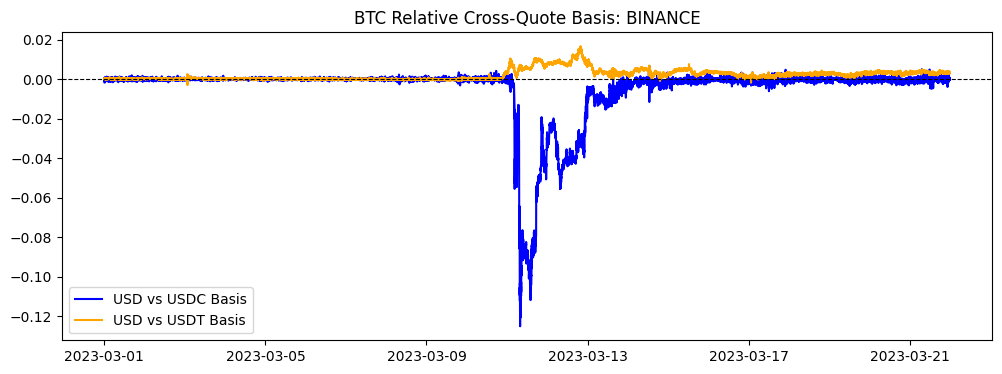

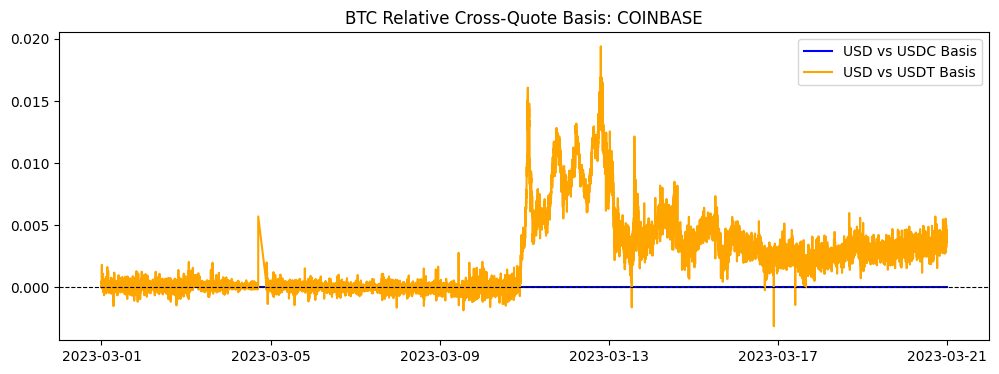

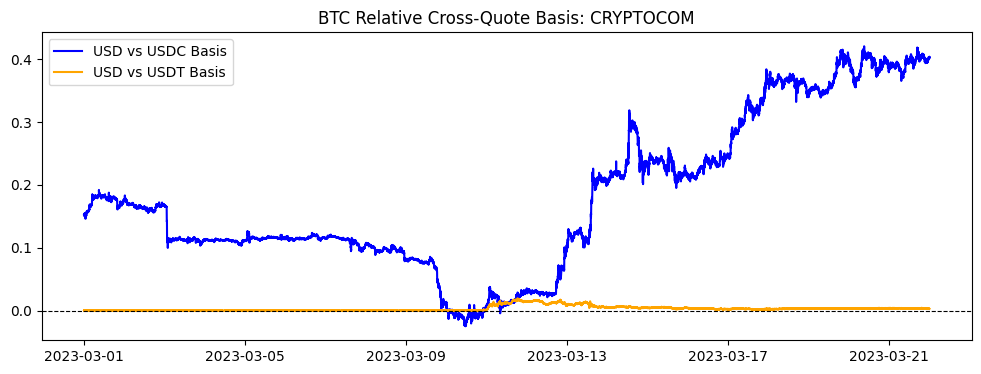

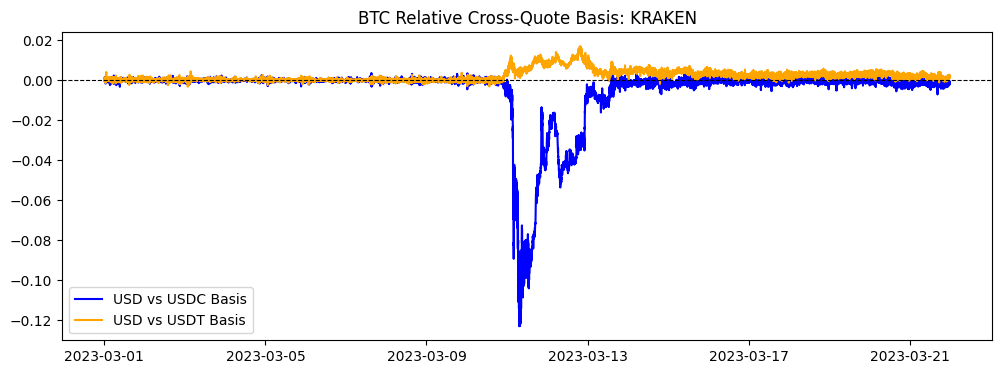

In [ ]:
asset = "BTC"

for exch in ["binance", "coinbase", "cryptocom", "kraken"]:
    plt.figure(figsize=(12, 4))

    usd_k  = f"{exch}_{asset}USD"
    usdc_k = f"{exch}_{asset}USDC"
    usdt_k = f"{exch}_{asset}USDT"

    # Plot USD vs USDC (Blue line)
    if usd_k in all_data and usdc_k in all_data:
        p_usd, p_usdc = all_data[usd_k]['close'], all_data[usdc_k]['close']
        df_tmp = pd.concat([p_usd, p_usdc], axis=1).dropna()
        basis_usdc = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]
        plt.plot(basis_usdc.index, basis_usdc, label="USD vs USDC Basis", color="blue")

    # Plot USD vs USDT (Orange line)
    if usd_k in all_data and usdt_k in all_data:
        p_usd, p_usdt = all_data[usd_k]['close'], all_data[usdt_k]['close']
        df_tmp = pd.concat([p_usd, p_usdt], axis=1).dropna()
        basis_usdt = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]
        plt.plot(basis_usdt.index, basis_usdt, label="USD vs USDT Basis", color="orange")

    plt.axhline(0, color="black", lw=0.8, ls="--")
    plt.title(f"{asset} Relative Cross-Quote Basis: {exch.upper()}")
    plt.legend()
    plt.show()

# Regime Switch

We model the basis series $\{b_t\}$ using a two-state Markov-switching mean specification:
$$
b_t = \mu_{S_t} + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2),
$$
where $S_t \in \{0,1\}$ follows a first-order Markov chain. The fitted model identifies a sharp shift in the
conditional mean around the shock date: $\widehat{\mu}_0 \approx -2.1\times 10^{-5}$ and
$\widehat{\mu}_1 \approx 5.45\times 10^{-3}$, implying $\Delta\widehat{\mu}\approx 5.47\times 10^{-3}$
(about $54.7$ bps). The smoothed regime probabilities transition rapidly from the low-mean regime to the
high-mean regime and remain elevated thereafter, consistent with a persistent level shift rather than
transitory noise.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)



REGIME SUMMARY: BINANCE
                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                30240
Model:               MarkovRegression   Log Likelihood              151454.383
Date:                Tue, 24 Feb 2026   AIC                        -302898.766
Time:                        06:58:37   BIC                        -302857.182
Sample:                    03-01-2023   HQIC                       -302885.428
                         - 03-21-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012   1.02e-05    117.628      0.000       0.001       0.001
                           

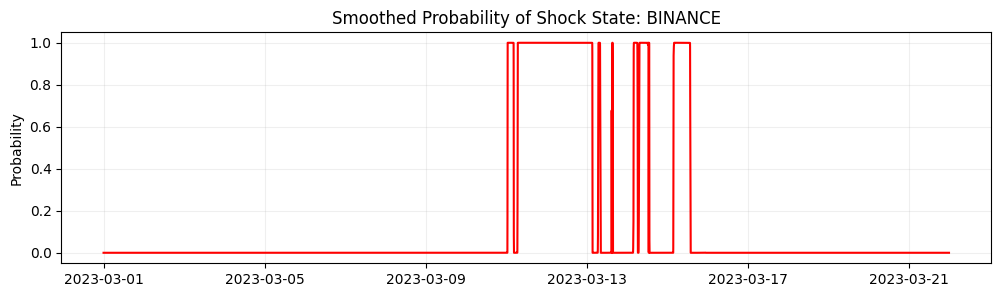

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



REGIME SUMMARY: COINBASE
                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                28519
Model:               MarkovRegression   Log Likelihood              139215.721
Date:                Tue, 24 Feb 2026   AIC                        -278421.442
Time:                        06:58:54   BIC                        -278380.150
Sample:                             0   HQIC                       -278408.161
                              - 28519                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013   1.23e-05    103.334      0.000       0.001       0.001
                          

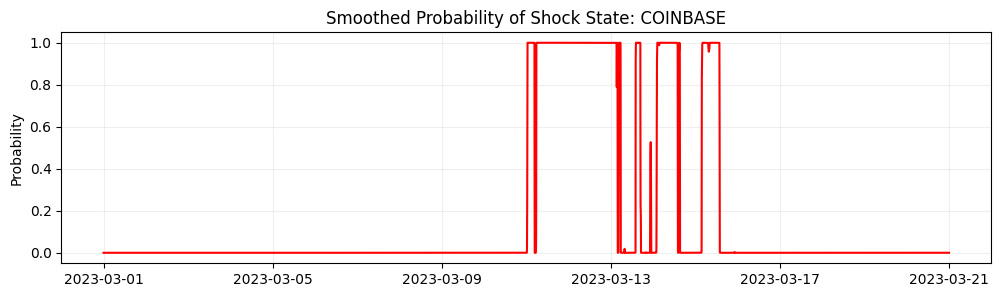

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)



REGIME SUMMARY: CRYPTOCOM
                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                30240
Model:               MarkovRegression   Log Likelihood              145244.069
Date:                Tue, 24 Feb 2026   AIC                        -290478.137
Time:                        06:59:15   BIC                        -290436.553
Sample:                    03-01-2023   HQIC                       -290464.800
                         - 03-21-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016   1.22e-05    127.055      0.000       0.002       0.002
                         

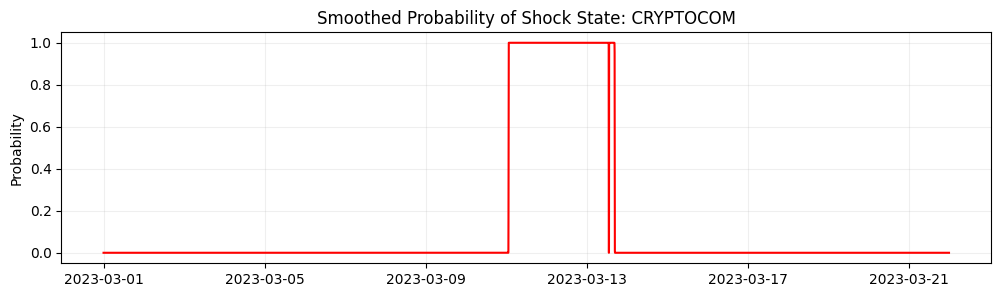


REGIME SUMMARY: KRAKEN
                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                30239
Model:               MarkovRegression   Log Likelihood              148993.879
Date:                Tue, 24 Feb 2026   AIC                        -297977.758
Time:                        06:59:36   BIC                        -297936.174
Sample:                    03-01-2023   HQIC                       -297964.420
                         - 03-21-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012    1.2e-05     98.073      0.000       0.001       0.001
                            

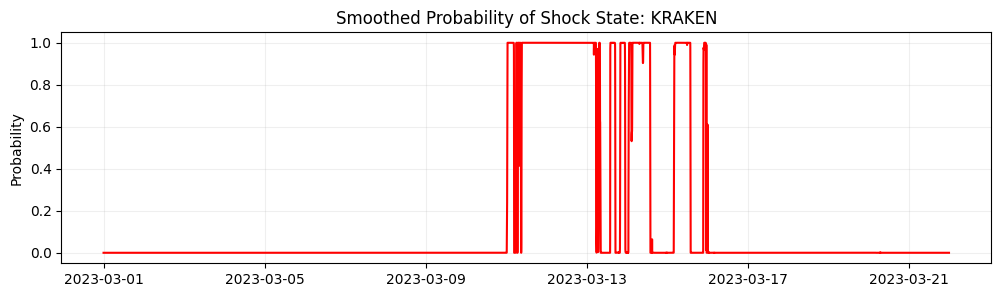

In [ ]:
exchanges = sorted(list(set(key.split('_')[0] for key in all_data.keys())))
asset = "BTC"

for exch in exchanges:
    usd_k  = f"{exch}_{asset}USD"
    usdt_k = f"{exch}_{asset}USDT"

    if usd_k in all_data and usdt_k in all_data:
        # Calculate Basis: (P_USD - P_USDT) / P_USDT
        p_usd = all_data[usd_k]['close']
        p_usdt = all_data[usdt_k]['close']
        df_tmp = pd.concat([p_usd, p_usdt], axis=1).dropna()
        y = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]
        y = y.replace([np.inf, -np.inf], np.nan).dropna().astype(float)

        if len(y) > 100:
            try:
                # 3. Fit Markov Regression
                # k_regimes=2: models 'stable' vs 'shock' states
                mod = MarkovRegression(y, k_regimes=2, trend="c", switching_variance=False)
                res = mod.fit(disp=False)

                print(f"\n{'='*30}\nREGIME SUMMARY: {exch.upper()}\n{'='*30}")
                print(res.summary())

                fig, ax = plt.subplots(figsize=(12, 3))
                ax.plot(res.smoothed_marginal_probabilities[1], color='red', label='Prob(Regime 1)')
                ax.set_title(f"Smoothed Probability of Shock State: {exch.upper()}")
                ax.set_ylabel("Probability")
                ax.grid(alpha=0.2)
                plt.show()

            except Exception as e:
                print(f"Could not fit model for {exch.upper()}: {e}")
    else:
        print(f"Skipping {exch.upper()}: Missing required USD/USDT pairs.")


--- BINANCE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


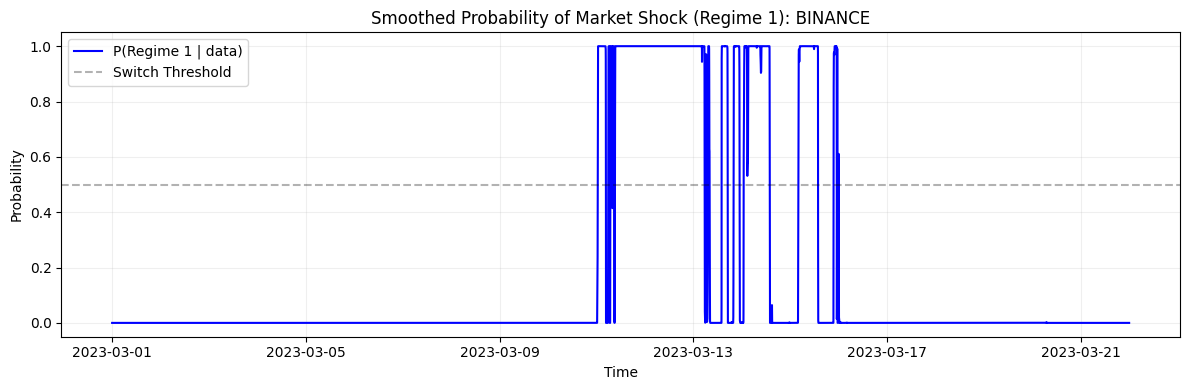


--- BINANCE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


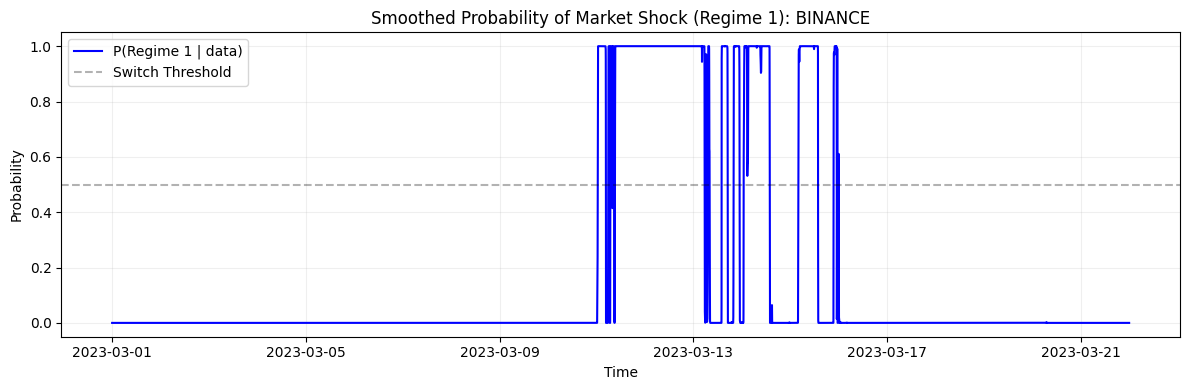


--- BINANCE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


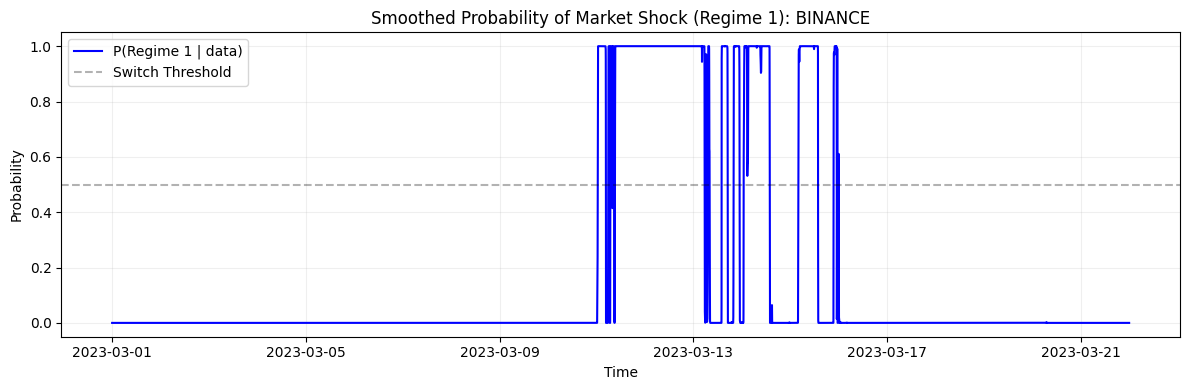


--- BINANCE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


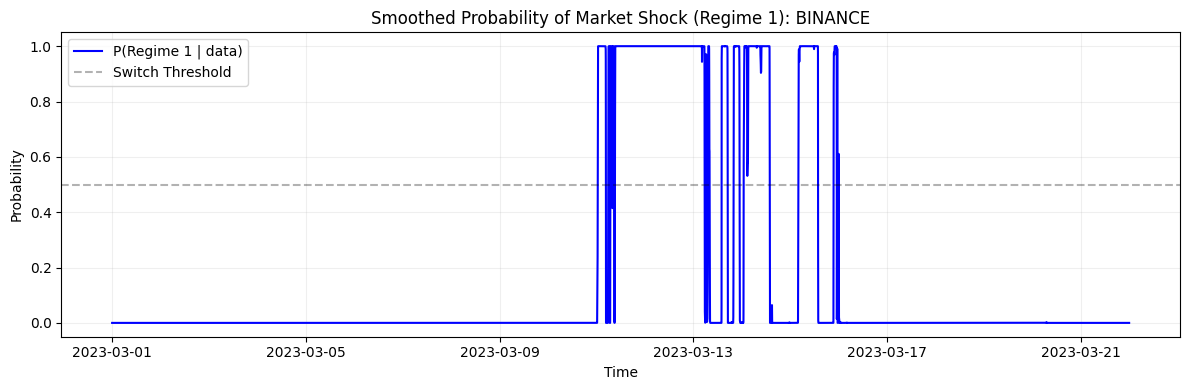


--- BINANCE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


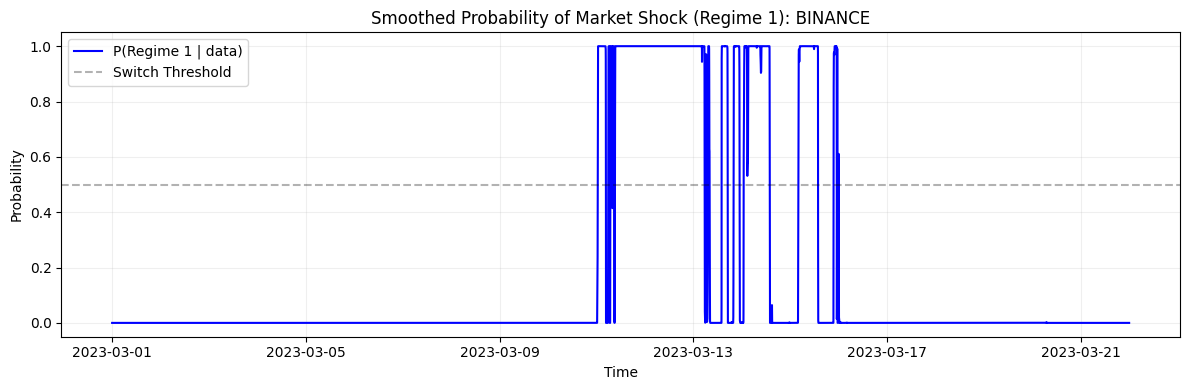


--- COINBASE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


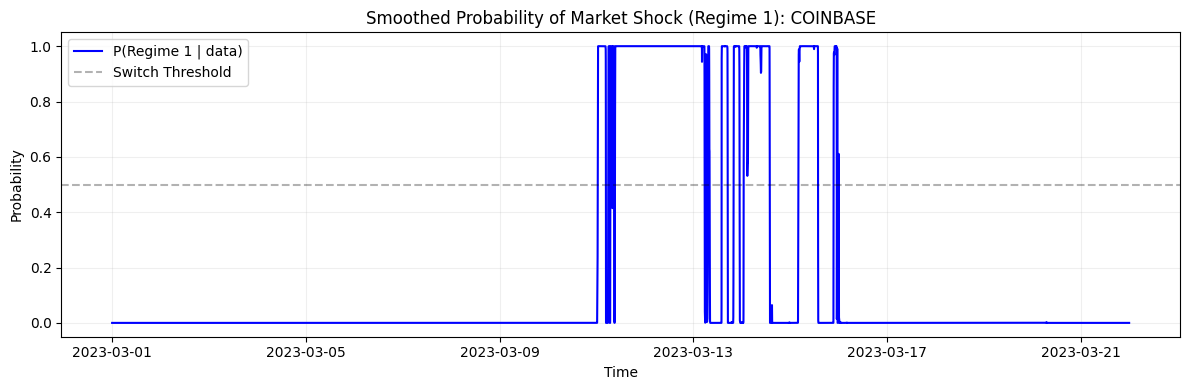


--- COINBASE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


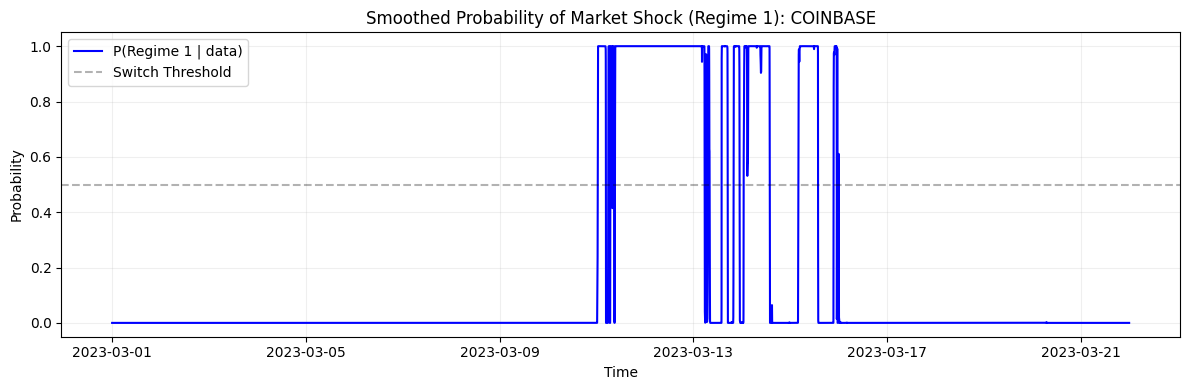


--- COINBASE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


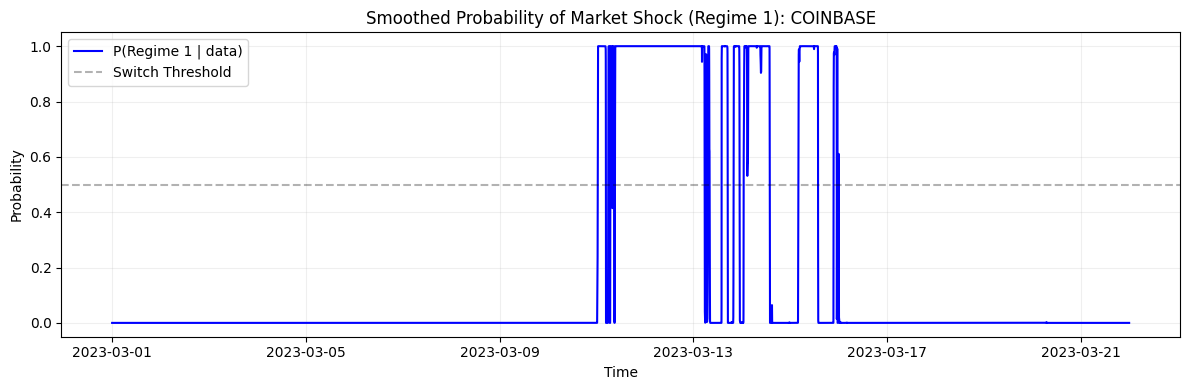


--- COINBASE ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


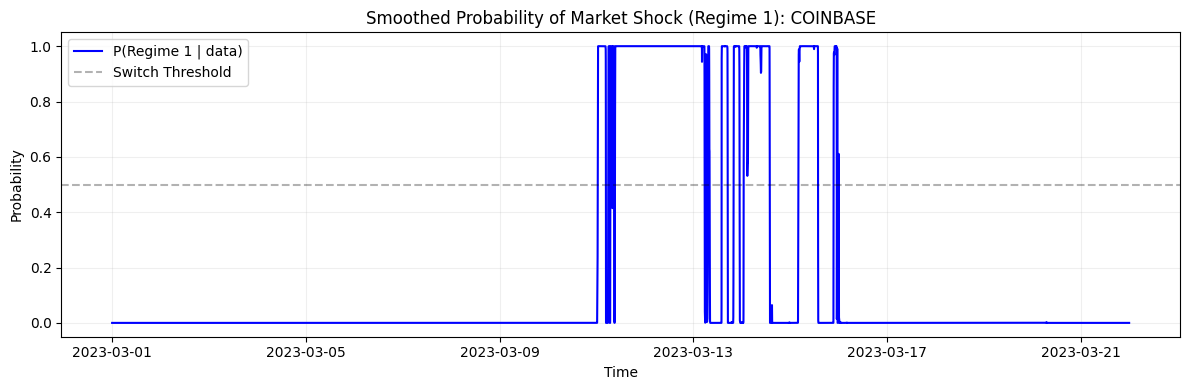


--- CRYPTOCOM ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


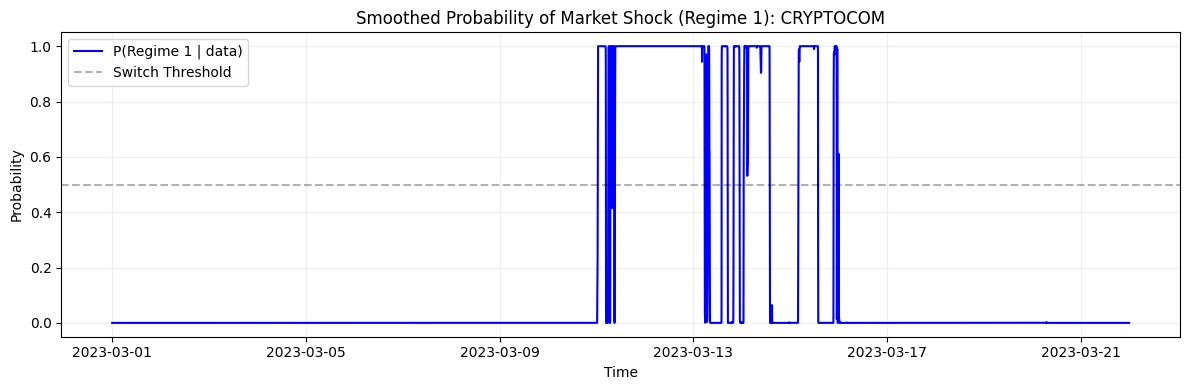


--- CRYPTOCOM ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


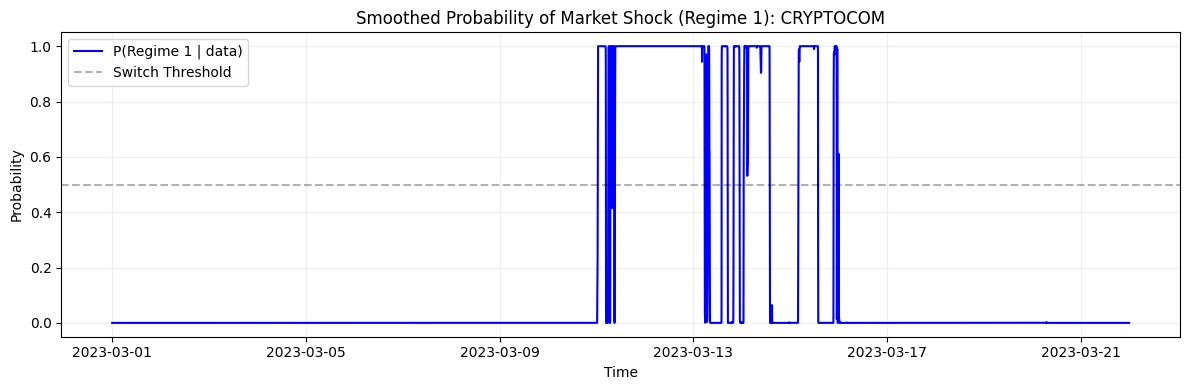


--- CRYPTOCOM ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


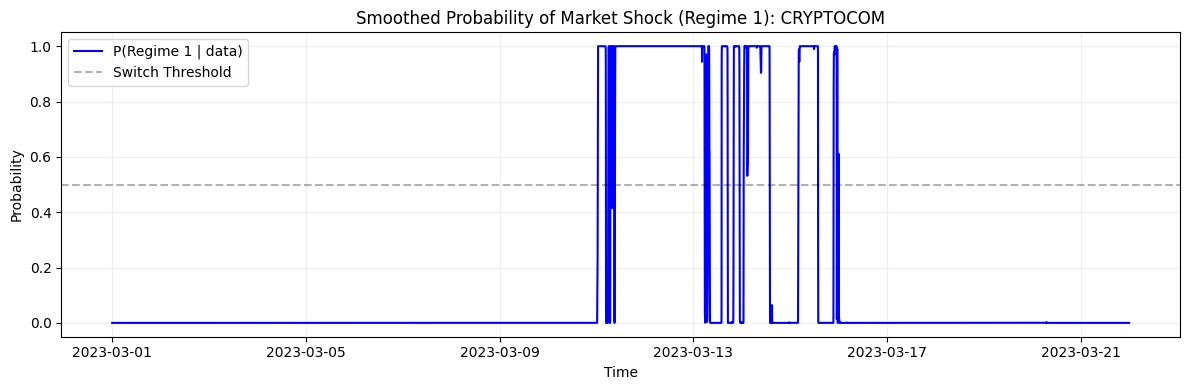


--- CRYPTOCOM ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


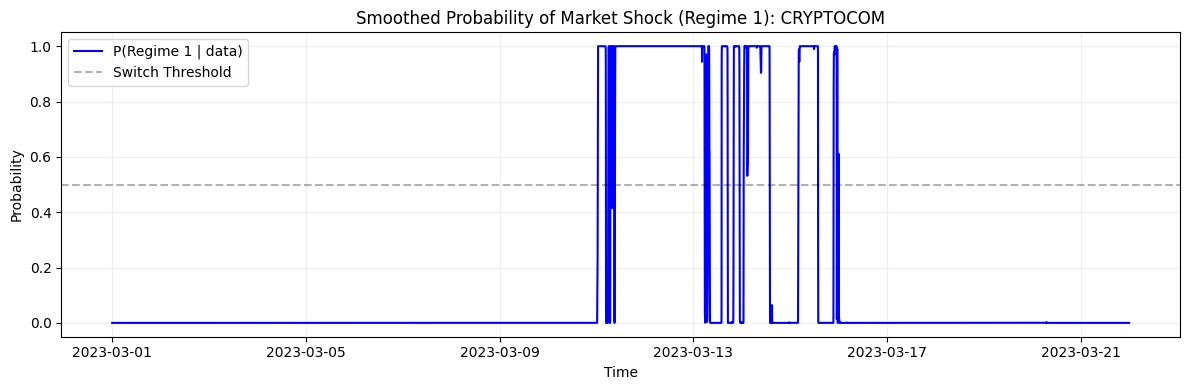


--- KRAKEN ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


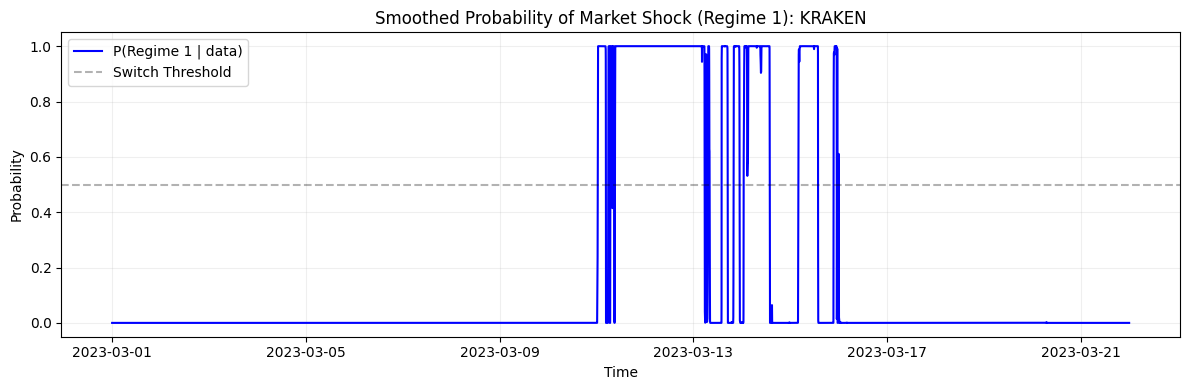


--- KRAKEN ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


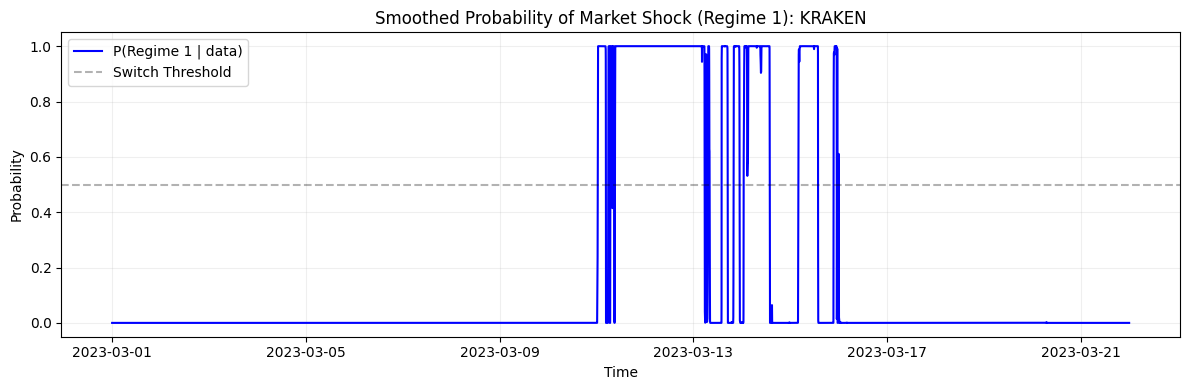


--- KRAKEN ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


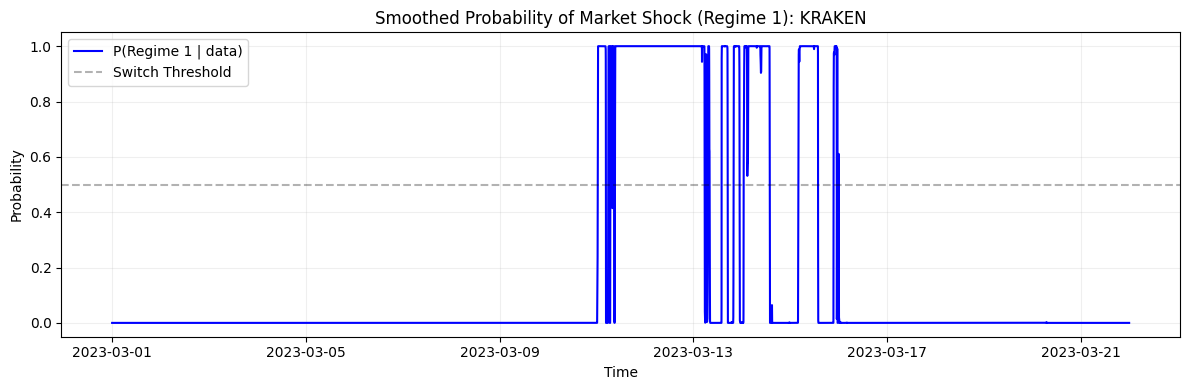


--- KRAKEN ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


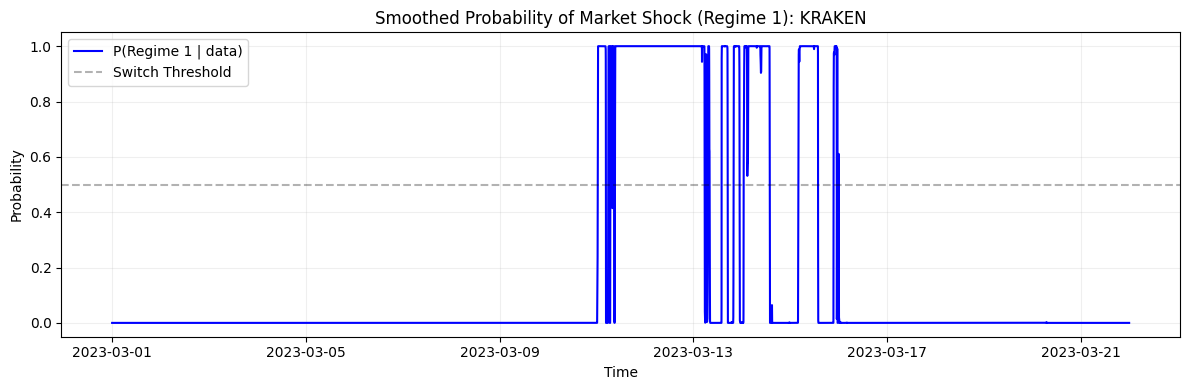


--- KRAKEN ANALYSIS ---
Regime 0 Mean (Stable): 0.001175
Regime 1 Mean (Shock):  0.007093


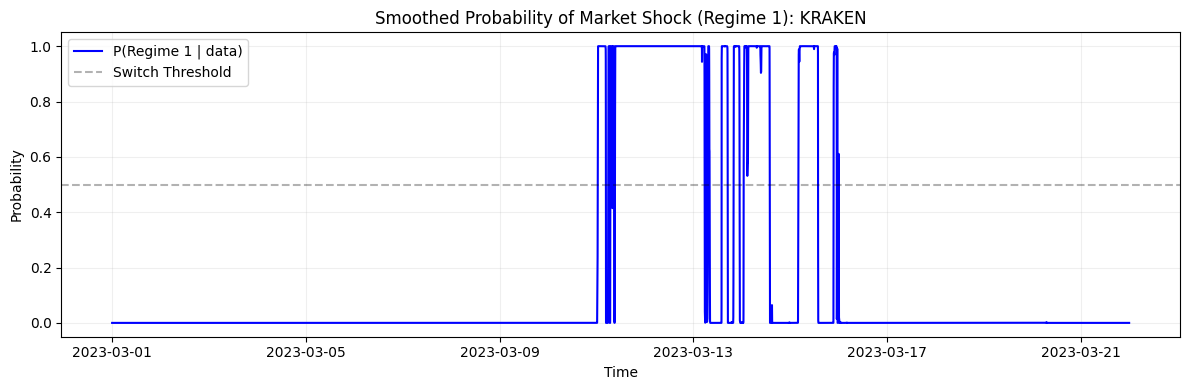

In [ ]:
for key, df_exch in all_data.items():
    exchange_name = key.split('_')[0].upper()

    # 1. Access regime-specific intercepts (means)
    regime_0_mean = res.params['const[0]']
    regime_1_mean = res.params['const[1]']

    print(f"\n--- {exchange_name} ANALYSIS ---")
    print(f"Regime 0 Mean (Stable): {regime_0_mean:.6f}")
    print(f"Regime 1 Mean (Shock):  {regime_1_mean:.6f}")

    # 2. Get smoothed marginal probabilities
    p_sm = res.smoothed_marginal_probabilities

    plt.figure(figsize=(12, 4))
    plt.plot(p_sm.index, p_sm[1], label="P(Regime 1 | data)", color='blue', lw=1.5)
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.3, label="Switch Threshold")

    plt.title(f"Smoothed Probability of Market Shock (Regime 1): {exchange_name}")

    plt.ylabel("Probability")
    plt.xlabel("Time")
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='upper left')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [ ]:
asset = "BTC"
all_stats = []

for exch in sorted(list(set(key.split('_')[0] for key in all_data.keys()))):
    usd_k  = f"{exch}_{asset}USD"
    usdt_k = f"{exch}_{asset}USDT"

    if usd_k in all_data and usdt_k in all_data:
        p_usd, p_usdt = all_data[usd_k]['close'], all_data[usdt_k]['close']
        df_tmp = pd.concat([p_usd, p_usdt], axis=1).dropna()
        y_series = (df_tmp.iloc[:,0] - df_tmp.iloc[:,1]) / df_tmp.iloc[:,1]
        y_series = y_series.replace([np.inf, -np.inf], np.nan).dropna()

        try:
            # --- MODEL FITTING ---
            from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
            mod = MarkovRegression(y_series, k_regimes=2, trend="c", switching_variance=False)
            res = mod.fit(disp=False)

            # --- PARAMETER EXTRACTION ---
            # Transition Matrix is (k_regimes x k_regimes)
            # p[i, j] is the probability of moving from regime j to regime i
            tm = res.regime_transition
            if tm.ndim == 3: tm = tm[:, :, 0] # Handle non-TVTP shape

            # Expected durations: 1 / (1 - p_ii)
            durations = res.expected_durations

            all_stats.append({
                "Exchange": exch.upper(),
                "Mean_Reg0": res.params.get('const[0]', np.nan),
                "Mean_Reg1": res.params.get('const[1]', np.nan),
                "P(0->0)": tm[0, 0], # Probability of staying in stable state
                "P(1->1)": tm[1, 1], # Probability of staying in shock state
                "Duration_Reg0": durations[0],
                "Duration_Reg1": durations[1]
            })

        except Exception as e:
            print(f"Skipping {exch.upper()}: {e}")

regime_summary = pd.DataFrame(all_stats)
display(regime_summary)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


,Exchange,Mean_Reg0,Mean_Reg1,P(0->0),P(1->1),Duration_Reg0,Duration_Reg1
0,BINANCE,0.001204,0.007211,0.999672,0.997859,3051.478399,466.996692
1,COINBASE,0.001276,0.007707,0.999679,0.998278,3113.690057,580.723831
2,CRYPTOCOM,0.001551,0.012097,0.999929,0.999442,14020.103646,1791.871926
3,KRAKEN,0.001175,0.007093,0.999454,0.997144,1831.794233,350.163452


In [ ]:
regime_hat = p_sm[1] > 0.5   # True when regime 1 is more likely
mean_reg1 = y[regime_hat].mean()
mean_reg0 = y[~regime_hat].mean()
print("Mean basis in Regime 0:", mean_reg0)
print("Mean basis in Regime 1:", mean_reg1)
print("Difference (Reg1 - Reg0):", mean_reg1 - mean_reg0)


Mean basis in Regime 0: 0.0011722860437827166
Mean basis in Regime 1: 0.00708321027494631
Difference (Reg1 - Reg0): 0.005910924231163593


                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                30239
Model:               MarkovRegression   Log Likelihood              161248.051
Date:                Tue, 24 Feb 2026   AIC                        -322484.103
Time:                        07:01:16   BIC                        -322434.201
Sample:                    03-01-2023   HQIC                       -322468.097
                         - 03-21-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.977e-05   3.85e-06     12.927      0.000    4.22e-05    5.73e-05
sigma2      1.961e-07        nan        nan        n

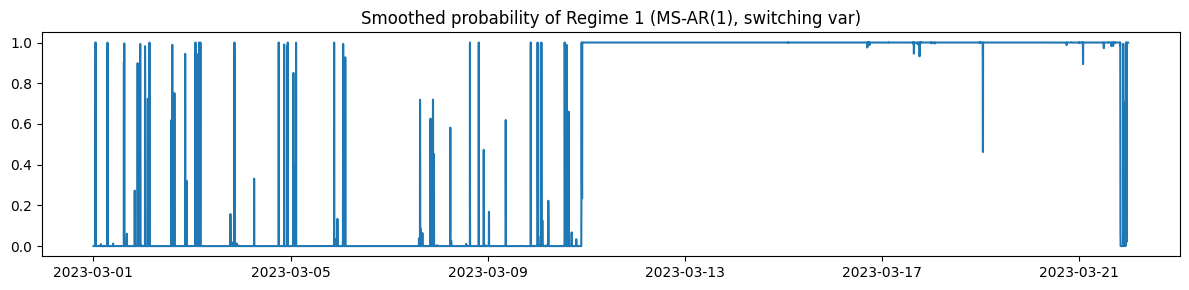

In [ ]:
mod2 = MarkovRegression(
    y,
    k_regimes=2,
    trend="c",
    order=1,                 # AR(1)
    switching_variance=True  # regime-dependent volatility (usually realistic)
)

res2 = mod2.fit(disp=False)
print(res2.summary())

p_sm2 = res2.smoothed_marginal_probabilities
plt.figure(figsize=(12,3))
plt.plot(p_sm2.index, p_sm2[1], label="P(Regime 1 | data)")
plt.title("Smoothed probability of Regime 1 (MS-AR(1), switching var)")
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm

# baseline: AR(1) (or try ARIMA(p,0,q))
ar1 = sm.tsa.ARIMA(y, order=(1,0,0)).fit()
print("AR(1) AIC:", ar1.aic, "BIC:", ar1.bic)

print("MS model AIC:", res.aic, "BIC:", res.bic)
print("MS-AR(1) model AIC:", res2.aic, "BIC:", res2.bic)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR(1) AIC: -359736.6446458103 BIC: -359711.6939825274
MS model AIC: -297977.75795185124 BIC: -297936.1735130464
MS-AR(1) model AIC: -322484.10268593 BIC: -322434.2013593642


In [ ]:
mod = MarkovRegression(
    y,
    k_regimes=2,
    trend="c",
    switching_variance=True
)
res = mod.fit(disp=False, maxiter=200)
print(res.summary())


                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                30239
Model:               MarkovRegression   Log Likelihood              161248.051
Date:                Tue, 24 Feb 2026   AIC                        -322484.103
Time:                        07:01:41   BIC                        -322434.201
Sample:                    03-01-2023   HQIC                       -322468.097
                         - 03-21-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.977e-05   3.85e-06     12.927      0.000    4.22e-05    5.73e-05
sigma2      1.961e-07        nan        nan        n

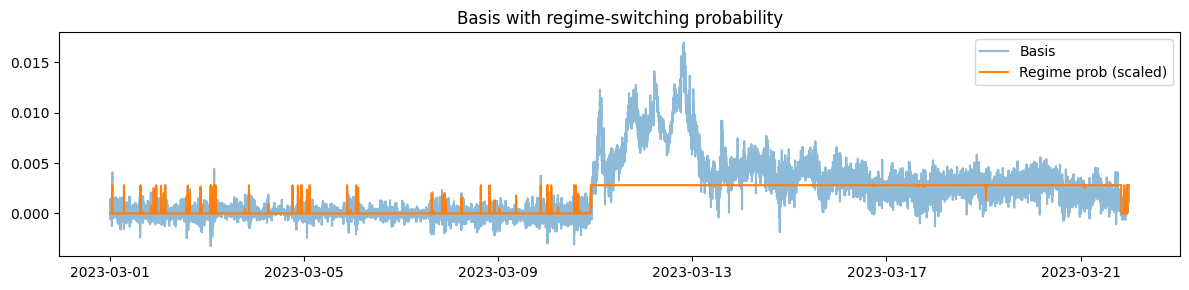

In [ ]:
p = res.smoothed_marginal_probabilities[1]

plt.figure(figsize=(12,3))
plt.plot(y.index, y, alpha=0.5, label="Basis")
plt.plot(p.index, p * y.std(), label="Regime prob (scaled)")
plt.legend()
plt.title("Basis with regime-switching probability")
plt.tight_layout()
plt.show()


In [ ]:
reg1 = p > 0.5
print("Mean regime 0:", y[~reg1].mean())
print("Mean regime 1:", y[reg1].mean())


Mean regime 0: 4.9505694727499806e-05
Mean regime 1: 0.004019613905128847


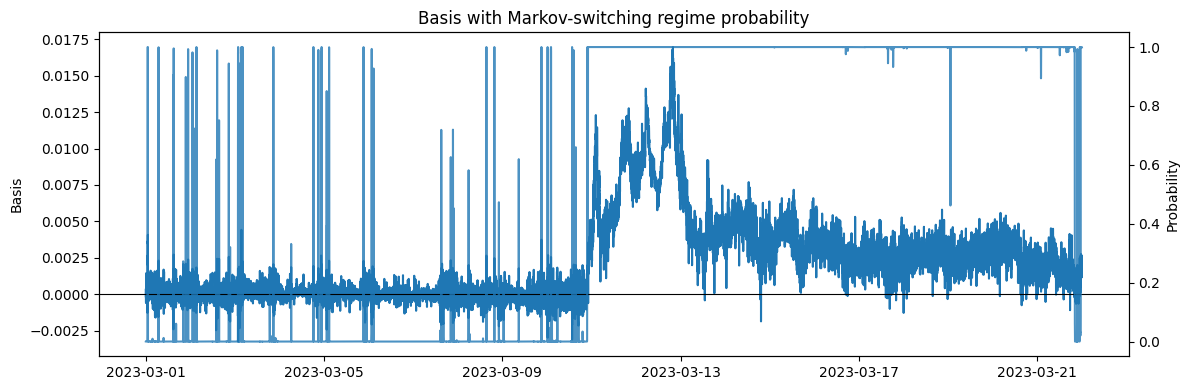

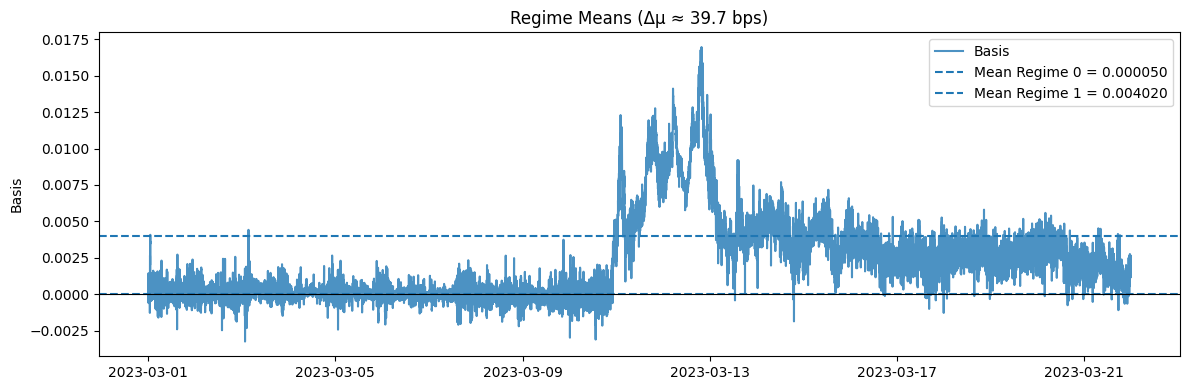

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(y.index, y, label="Basis")
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylabel("Basis")

ax2 = ax1.twinx()
ax2.plot(p.index, p, label="P(Regime=1)", alpha=0.8)
ax2.set_ylabel("Probability")
ax2.set_ylim(-0.05, 1.05)

ax1.set_title("Basis with Markov-switching regime probability")
fig.tight_layout()
plt.show()

mu0 = y[~reg1].mean()
mu1 = y[reg1].mean()
dmu_bps = (mu1 - mu0) * 1e4

plt.figure(figsize=(12,4))
plt.plot(y.index, y, label="Basis", alpha=0.8)
plt.axhline(mu0, ls="--", label=f"Mean Regime 0 = {mu0:.6f}")
plt.axhline(mu1, ls="--", label=f"Mean Regime 1 = {mu1:.6f}")
plt.axhline(0, color="black", lw=0.8)
plt.title(f"Regime Means (Δμ ≈ {dmu_bps:.1f} bps)")
plt.ylabel("Basis")
plt.legend()
plt.tight_layout()
plt.show()


# Binance

Loaded rows: 30240
Columns available: ['BTC-USD', 'BTC-USD volume', 'BTC-USDT', 'BTC-USDT volume', 'BTC-USDC', 'BTC-USDC volume']


,pair,zero_volume_minutes,total_minutes,pct_zero_volume
0,BTC-USDC,12971,30240,42.893519
1,BTC-USDT,658,30240,2.175926
2,BTC-USD,72,30240,0.238095


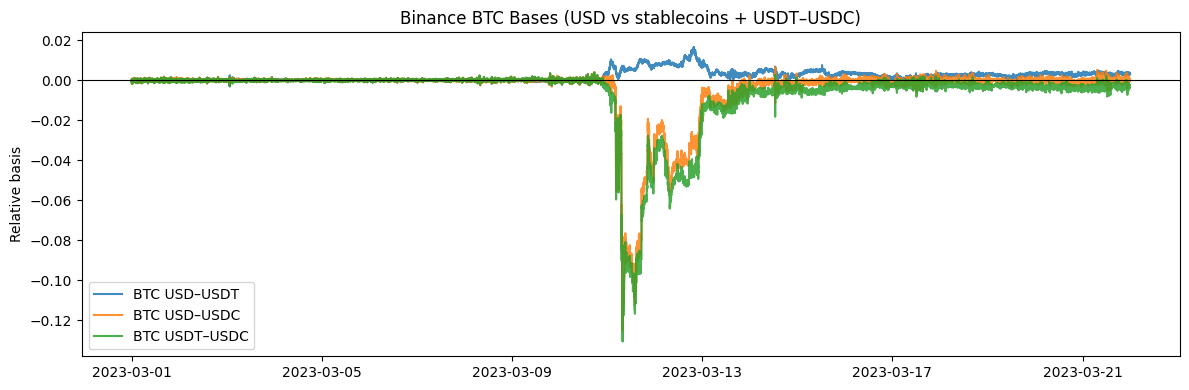

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)



MS model: Binance BTC USD–USDT basis
Mean regime 0: 8.864667614751004e-06
Mean regime 1: 0.003797833096145293
Δμ (bps): 37.88968428530542


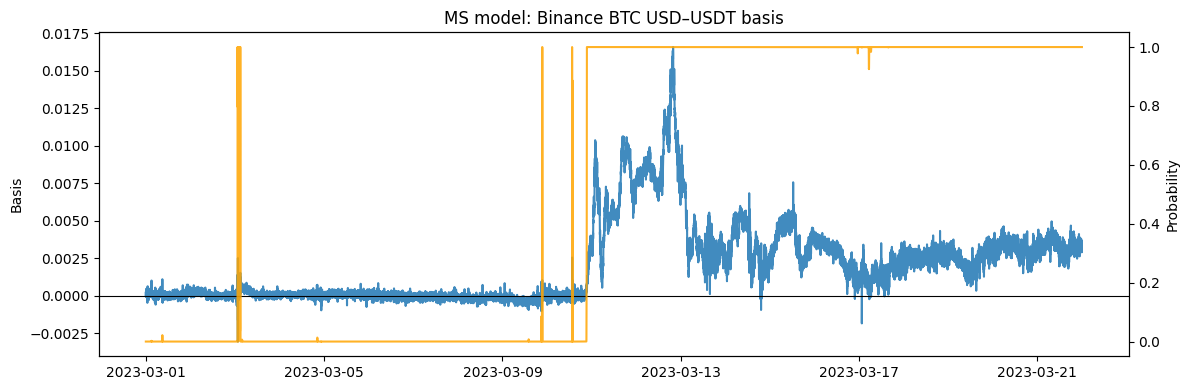

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)



MS model: Binance BTC USD–USDC basis
Mean regime 0: -0.00020422363085813357
Mean regime 1: -0.028983184282282404
Δμ (bps): -287.78960651424273


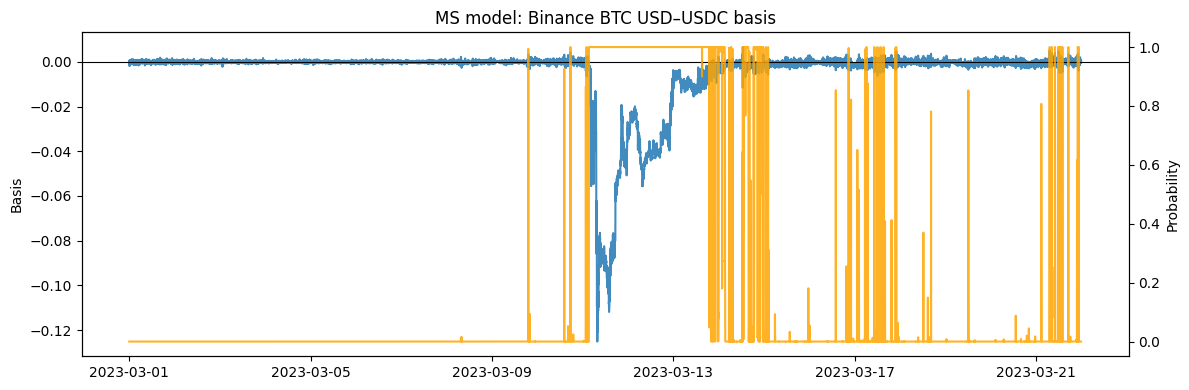

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)



MS model: Binance BTC USDT–USDC basis
Mean regime 0: -0.0015467765439932345
Mean regime 1: -0.03961089579829634
Δμ (bps): -380.6411925430311


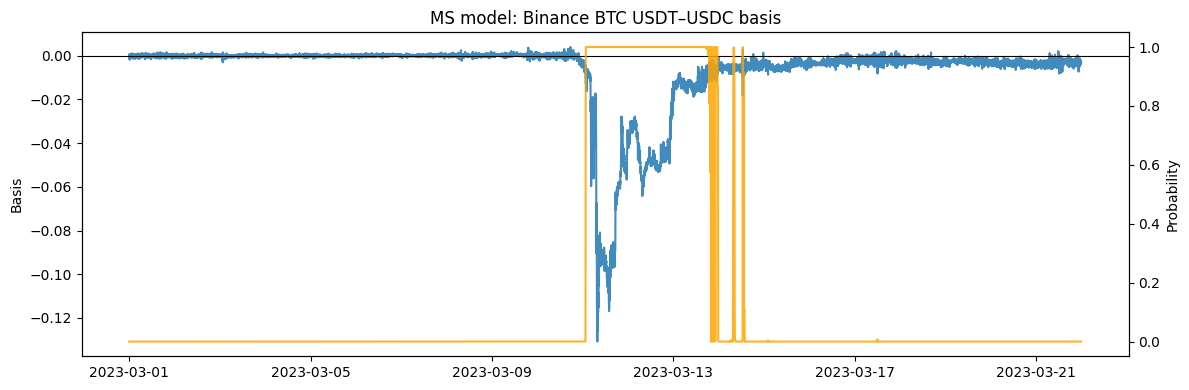

In [ ]:
target_exchange = "binance"
pairs = ["BTCUSD", "BTCUSDT", "BTCUSDC"]

df_list = []
for p in pairs:
    key = f"{target_exchange}_{p}"
    if key in all_data:
        temp_df = all_data[key][['close', 'volume']].copy()
        clean_name = f"{p[:3]}-{p[3:]}"
        temp_df.columns = [clean_name, f"{clean_name} volume"]
        df_list.append(temp_df)
    else:
        print(f"Warning: Key {key} not found in all_data")

if not df_list:
    raise ValueError("No Binance data found in all_data. Please run your loader cell first.")

df = pd.concat(df_list, axis=1).sort_index()
df = df.dropna(subset=["BTC-USD", "BTC-USDT", "BTC-USDC"])

print("Loaded rows:", len(df))
print("Columns available:", df.columns.tolist())


volume_cols = [c for c in df.columns if c.lower().endswith("volume")]
total_minutes = len(df)

zero_vol_rows = []
for col in volume_cols:
    pair = col.replace(" volume", "")
    s = pd.to_numeric(df[col], errors="coerce").fillna(0)
    zero_n = int((s == 0).sum())
    zero_vol_rows.append({
        "pair": pair,
        "zero_volume_minutes": zero_n,
        "total_minutes": total_minutes,
        "pct_zero_volume": 100.0 * zero_n / total_minutes
    })

zero_vol_summary = (
    pd.DataFrame(zero_vol_rows)
      .sort_values(["pct_zero_volume", "zero_volume_minutes"], ascending=False)
      .reset_index(drop=True)
)

display(zero_vol_summary)


needed = ["BTC-USD", "BTC-USDT", "BTC-USDC"]
for c in needed:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["basis_BTC_USD_USDT"]  = (df["BTC-USD"]  - df["BTC-USDT"]) / df["BTC-USDT"]
df["basis_BTC_USD_USDC"]  = (df["BTC-USD"]  - df["BTC-USDC"]) / df["BTC-USDC"]
df["basis_BTC_USDT_USDC"] = (df["BTC-USDT"] - df["BTC-USDC"]) / df["BTC-USDC"]

# Plot all three bases
plt.figure(figsize=(12,4))
plt.plot(df.index, df["basis_BTC_USD_USDT"],  label="BTC USD–USDT", alpha=0.85)
plt.plot(df.index, df["basis_BTC_USD_USDC"],  label="BTC USD–USDC", alpha=0.85)
plt.plot(df.index, df["basis_BTC_USDT_USDC"], label="BTC USDT–USDC", alpha=0.85)
plt.axhline(0, color="black", lw=0.8)
plt.title("Binance BTC Bases (USD vs stablecoins + USDT–USDC)")
plt.ylabel("Relative basis")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Markov-switching regime model helper
# -----------------------------
def fit_and_plot_ms(y, title):
    y_clean = y.replace([np.inf, -np.inf], np.nan).dropna()

    # Fit Model (k_regimes=2: Normal vs High Volatility/Stress)
    mod = MarkovRegression(y_clean, k_regimes=2, trend="c", switching_variance=True)
    res = mod.fit(disp=False, maxiter=500)

    p = res.smoothed_marginal_probabilities[1]
    reg = p > 0.5

    mu0 = y_clean[~reg].mean()
    mu1 = y_clean[ reg].mean()
    dmu_bps = (mu1 - mu0) * 1e4

    print(f"\n{title}")
    print("Mean regime 0:", mu0)
    print("Mean regime 1:", mu1)
    print("Δμ (bps):", dmu_bps)

    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(y_clean.index, y_clean, label="Basis", alpha=0.85)
    ax1.axhline(0, color="black", lw=0.8)
    ax1.set_ylabel("Basis")

    ax2 = ax1.twinx()
    ax2.plot(p.index, p, label="P(Regime=1)", alpha=0.85, color='orange')
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Probability")

    ax1.set_title(title)
    fig.tight_layout()
    plt.show()

    return res, p

# Run MS model on each basis
res_usd_usdt,  p_usd_usdt  = fit_and_plot_ms(df["basis_BTC_USD_USDT"],  "MS model: Binance BTC USD–USDT basis")
res_usd_usdc,  p_usd_usdc  = fit_and_plot_ms(df["basis_BTC_USD_USDC"],  "MS model: Binance BTC USD–USDC basis")
res_usdt_usdc, p_usdt_usdc = fit_and_plot_ms(df["basis_BTC_USDT_USDC"], "MS model: Binance BTC USDT–USDC basis")

In [ ]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.arima.model import ARIMA

y = df["basis_BTC_USD_USDC"].replace([np.inf, -np.inf], np.nan).dropna()

pre_end    = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
post_start = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")

y_pre  = y.loc[y.index < pre_end]
y_post = y.loc[y.index >= post_start]

print(f"Pre-event data (before March 10): {len(y_pre)} rows")
print(f"Post-event data (after March 14): {len(y_post)} rows")

Pre-event data (before March 10): 12960 rows
Post-event data (after March 14): 11520 rows


In [ ]:
y = df["basis_BTC_USD_USDC"].replace([np.inf, -np.inf], np.nan).dropna()

pre_end    = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
post_start = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")

y_pre  = y.loc[y.index < pre_end]
y_post = y.loc[y.index >= post_start]

print(f"Pre-event samples (Before Mar 10): {len(y_pre)}")
print(f"Post-event samples (After Mar 14): {len(y_post)}")

print("\n--- Summary Comparison ---")
print(f"Pre-event Mean:  {y_pre.mean() * 1e4:.4f} bps")
print(f"Post-event Mean: {y_post.mean() * 1e4:.4f} bps")
print(f"Difference:      {(y_post.mean() - y_pre.mean()) * 1e4:.4f} bps")


Pre-event samples (Before Mar 10): 12960
Post-event samples (After Mar 14): 11520

--- Summary Comparison ---
Pre-event Mean:  -0.2016 bps
Post-event Mean: -5.7948 bps
Difference:      -5.5932 bps


In [ ]:
# MA(1) pre
ma_pre = ARIMA(y_pre, order=(0,0,1)).fit()

# MA(1) post
ma_post = ARIMA(y_post, order=(0,0,1)).fit()

print("PRE period mean:", ma_pre.params["const"])
print("POST period mean:", ma_post.params["const"])
print("Δ mean (bps):", (ma_post.params["const"] - ma_pre.params["const"]) * 1e4)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be 

PRE period mean: -2.1355914509084716e-05
POST period mean: -0.0005821553407654365
Δ mean (bps): -5.607994262563518


In [ ]:
mu_pre  = y_pre.mean()
mu_post = y_post.mean()

print("PRE mean:", mu_pre)
print("POST mean:", mu_post)
print("Δ mean (bps):", (mu_post - mu_pre) * 1e4)


PRE mean: -2.016324538972372e-05
POST mean: -0.0005794783358432466
Δ mean (bps): -5.593150904535229


## 2025

In [ ]:
y = df["basis_BTC_USD_USDC"].replace([np.inf, -np.inf], np.nan).dropna()

pre_end    = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
post_start = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")

y_pre  = y.loc[y.index < pre_end]
y_post = y.loc[y.index >= post_start]

print(f"Pre-event samples (Before Mar 10): {len(y_pre)}")
print(f"Post-event samples (After Mar 14): {len(y_post)}")

print("\n--- Summary Comparison ---")
print(f"Pre-event Mean:  {y_pre.mean() * 1e4:.4f} bps")
print(f"Post-event Mean: {y_post.mean() * 1e4:.4f} bps")
print(f"Difference:      {(y_post.mean() - y_pre.mean()) * 1e4:.4f} bps")

Pre-event samples (Before Mar 10): 12960
Post-event samples (After Mar 14): 11520

--- Summary Comparison ---
Pre-event Mean:  -0.2016 bps
Post-event Mean: -5.7948 bps
Difference:      -5.5932 bps


In [ ]:
search_root = "/content/drive/MyDrive/Yield Curve Surfers/Data/"

print("Starting Deep Search for 2025 data...\n")

found_files = []

for root, dirs, files in os.walk(search_root):
    for file in files:
        if "summary" in file.lower() or "2025" in file:
            full_path = os.path.join(root, file)
            found_files.append(full_path)
            print(f" FOUND: {full_path}")

if not found_files:
    print("\n No 'Summary' or '2025' files found in the Data folder.")
    print("Listing top-level folders to help you navigate:")
    try:
        print(f"Folders in {search_root}:", os.listdir(search_root))
    except:
        print("Could not access the Data folder. Is Drive mounted?")
else:
    print(f"\n Found {len(found_files)} potential files.")

    candidate = found_files[0]
    print(f"\n--- Testing Candidate: {os.path.basename(candidate)} ---")
    try:
        sample_df = pd.read_csv(candidate, nrows=5)
        print("Column Names found:")
        print(sample_df.columns.tolist())

        if 'timestamp' in sample_df.columns:
            full_temp = pd.read_csv(candidate, usecols=['timestamp'])
            full_temp['timestamp'] = pd.to_datetime(full_temp['timestamp'])
            print(f"Date Range in this file: {full_temp['timestamp'].min()} to {full_temp['timestamp'].max()}")
    except Exception as e:
        print(f"Could not read sample from {candidate}: {e}")

print("\n Copy the 'FOUND' path above that looks correct and paste it into the FILE_2025 variable in your analysis code.")

🔍 Starting Deep Search for 2025 data...

✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/data_gap_summary.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDT_1m_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDT_1d_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDT_1h_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDC_1m_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDC_1h_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDC_1d_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSD_1m_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSD_1h_2025.csv
✨ FOUND: /content/drive/MyDrive/Yield Curve Surfers

In [ ]:
binance_2025_files = {
    "BTC-USD":  "/content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSD_1m_2025.csv",
    "BTC-USDT": "/content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDT_1m_2025.csv",
    "BTC-USDC": "/content/drive/MyDrive/Yield Curve Surfers/Data/Binance/Extra Data/Binance_BTCUSDC_1m_2025.csv"
}

def convert_ts(series):
    """Flexible timestamp converter for strings, ms, or seconds."""
    ts_converted = pd.to_datetime(series, errors='coerce', utc=True)

    if ts_converted.isna().mean() > 0.8:
        nums = pd.to_numeric(series, errors='coerce')
        if nums.dropna().iloc[0] > 1e12: # Milliseconds
            return pd.to_datetime(nums, unit='ms', utc=True)
        else: # Seconds
            return pd.to_datetime(nums, unit='s', utc=True)
    return ts_converted

df_list_25 = []

for pair_name, file_path in binance_2025_files.items():
    if os.path.exists(file_path):
        print(f"Loading {pair_name}...")
        tmp = pd.read_csv(file_path)
        tmp.columns = tmp.columns.str.strip()

        t_col = next((c for c in ['ts', 'timestamp', 'open_time'] if c in tmp.columns), None)
        if not t_col:
            print(f"❌ Skipping {pair_name}: No time column found.")
            continue

        tmp['timestamp'] = convert_ts(tmp[t_col])
        close_col = next((c for c in ['close', 'Close'] if c in tmp.columns), 'close')
        vol_col = next((c for c in ['vol', 'volume', 'Volume'] if c in tmp.columns), 'vol')

        tmp = tmp.groupby('timestamp').agg({
            close_col: 'mean',
            vol_col: 'sum'
        }).sort_index()

        tmp.columns = [pair_name, f"{pair_name} volume"]
        df_list_25.append(tmp)
    else:
        print(f"❌ File not found: {file_path}")

if df_list_25:
    df25 = pd.concat(df_list_25, axis=1).sort_index().dropna()
    print(f"\n✅ Successfully created df25 with {len(df25)} rows.")
    print(f"Date range: {df25.index.min()} to {df25.index.max()}")
    display(df25.head())
else:
    print("No data loaded. Please double-check your Drive connection.")

Loading BTC-USD...
Loading BTC-USDT...
Loading BTC-USDC...

✅ Successfully created df25 with 452821 rows.
Date range: 2025-02-19 13:00:00+00:00 to 2025-12-31 00:00:00+00:00


,BTC-USD,BTC-USD volume,BTC-USDT,BTC-USDT volume,BTC-USDC,BTC-USDC volume
timestamp,,,,,,
2025-02-19 13:00:00+00:00,25073.21,0.0,96210.44,0.00000,96179.31,0.00294
2025-02-19 13:01:00+00:00,25073.21,0.0,96243.77,0.00125,96178.32,0.00021
2025-02-19 13:02:00+00:00,25073.21,0.0,96243.77,0.00000,96178.32,0.00000
2025-02-19 13:03:00+00:00,25073.21,0.0,96243.77,0.00000,96142.59,0.00087
2025-02-19 13:04:00+00:00,25073.21,0.0,96243.77,0.00000,96172.01,0.00030


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Yield Curve Surfers/Data/Binance/cleaned/"
FILE_2025 = os.path.join(BASE_PATH, "Summary_binance.csv")

if not os.path.exists(FILE_2025):
    print(f"❌ Still can't find the file at: {FILE_2025}")
    print("Files actually in that folder are:")
    print(os.listdir(BASE_PATH))
else:
    df25_full = pd.read_csv(FILE_2025)
    df25_full.columns = df25_full.columns.map(lambda x: str(x).strip())
    df25_full["timestamp"] = pd.to_datetime(df25_full["timestamp"])

    if df25_full["timestamp"].dt.tz is None:
        df25_full["timestamp"] = df25_full["timestamp"].dt.tz_localize("UTC")

    df25_full = df25_full.set_index("timestamp").sort_index()

    df25 = df25_full[df25_full.index.year == 2025].copy()

    if df25.empty:
        print("⚠️ Warning: The file was found, but it contains no 2025 data.")
        print(f"Date range in file: {df25_full.index.min()} to {df25_full.index.max()}")
    else:
        print(f"✅ Success! Loaded df25 with {len(df25)} rows.")
        volume_cols = [c for c in df25.columns if "volume" in c.lower()]

        zero_vol_25 = []
        T = len(df25)

        for c in volume_cols:
            s = pd.to_numeric(df25[c], errors="coerce").fillna(0)
            zero_n = int((s == 0).sum())
            pair_name = c.lower().replace("volume", "").strip().upper()

            zero_vol_25.append({
                "pair": pair_name,
                "zero_volume_minutes": zero_n,
                "total_minutes": T,
                "pct_zero_volume": 100 * zero_n / T
            })

        zero_vol_25_df = pd.DataFrame(zero_vol_25).sort_values("pct_zero_volume", ascending=False)
        display(zero_vol_25_df)

❌ Still can't find the file at: /content/drive/MyDrive/Yield Curve Surfers/Data/Binance/cleaned/Summary_binance.csv
Files actually in that folder are:
['binance_BTCUSDC_1m_20230301_20230321_cleaned.csv', 'binanceus_USDTUSD_1m_20230301_20230321_cleaned.csv', 'binance_BTCUSD_1m_20230301_20230321_cleaned.csv', 'binanceus_USDCUSD_1m_20230301_20230321_cleaned.csv', 'binance_BTCUSDT_1m_20230301_20230321_cleaned.csv']


/tmp/ipython-input-3713478375.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df25_hourly = df25.resample('1H').mean()


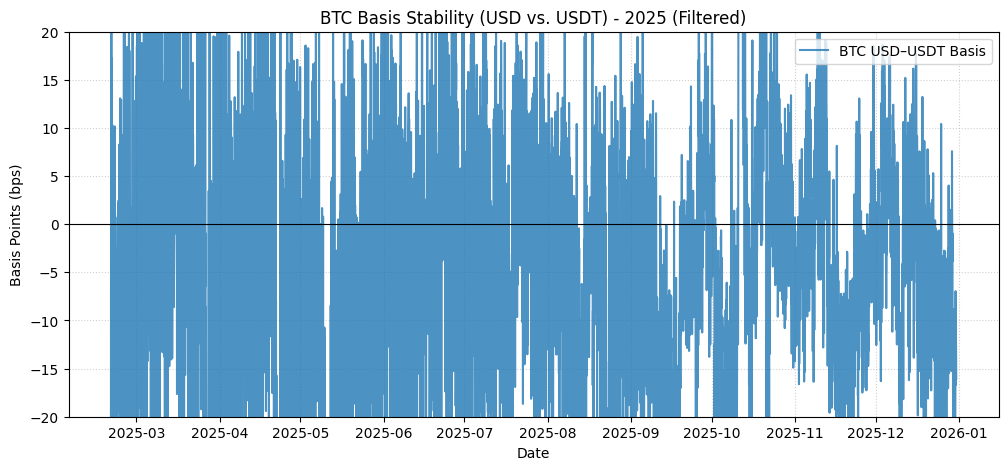

In [ ]:
if 'df25' not in locals():
    raise NameError("df25 not found. Please run your data loading cell (Cell 46/47) before this one.")

# We multiply by 1e4 later to get Basis Points (bps)
df25["basis_BTC_USD_USDT"] = (df25["BTC-USD"] - df25["BTC-USDT"]) / df25["BTC-USDT"]
df25["basis_BTC_USD_USDC"] = (df25["BTC-USD"] - df25["BTC-USDC"]) / df25["BTC-USDC"]
df25["basis_BTC_USDT_USDC"] = (df25["BTC-USDT"] - df25["BTC-USDC"]) / df25["BTC-USDC"]

# Using .mean() removes the 1-minute noise for a cleaner graph
df25_hourly = df25.resample('1H').mean()

plt.figure(figsize=(12, 5))
plt.plot(df25_hourly.index, df25_hourly["basis_BTC_USD_USDT"] * 1e4,
         color='#1f77b4', linewidth=1.5, alpha=0.8, label="BTC USD–USDT Basis")

plt.ylim(-20, 20)

plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
if 'EVENT_2025' in locals():
    plt.axvline(EVENT_2025, color='red', linestyle='--', label="GENIUS Act Implementation")

plt.ylabel("Basis Points (bps)")
plt.xlabel("Date")
plt.title("BTC Basis Stability (USD vs. USDT) - 2025 (Filtered)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.savefig("Basis_Timeline_Filtered.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
EVENT_2025 = pd.Timestamp("2025-07-18", tz="UTC")

def analyze_event(df, column_name):
    pre_event = df[df.index < EVENT_2025][column_name]
    post_event = df[df.index >= EVENT_2025][column_name]

    diff = (post_event.mean() - pre_event.mean()) * 10000
    print(f"Analysis for {column_name}:")
    print(f"  Pre-Event Mean:  {pre_event.mean()*10000:.2f} bps")
    print(f"  Post-Event Mean: {post_event.mean()*10000:.2f} bps")
    print(f"  Shift in Basis:  {diff:.2f} bps")
    print("-" * 30)

analyze_event(df25, "basis_BTC_USD_USDT")

Analysis for basis_BTC_USD_USDT:
  Pre-Event Mean:  -11.46 bps
  Post-Event Mean: -3.86 bps
  Shift in Basis:  7.60 bps
------------------------------


In [ ]:
print("--- 2025 Basis Statistics (in Basis Points) ---")
for col in ["basis_BTC_USD_USDT", "basis_BTC_USD_USDC", "basis_BTC_USDT_USDC"]:
    bps = df25[col] * 10000
    print(f"{col}: Mean={bps.mean():.2f}bps, Vol={bps.std():.2f}bps, Max={bps.max():.2f}bps")

--- 2025 Basis Statistics (in Basis Points) ---
basis_BTC_USD_USDT: Mean=-7.45bps, Vol=77.92bps, Max=293.82bps
basis_BTC_USD_USDC: Mean=-7.30bps, Vol=77.94bps, Max=282.14bps
basis_BTC_USDT_USDC: Mean=0.16bps, Vol=15.52bps, Max=192.41bps


In [ ]:
print("--- 2025 Basis Stats (in bps) ---")
for col in ["basis_BTC_USD_USDT", "basis_BTC_USD_USDC", "basis_BTC_USDT_USDC"]:
    # 1 bps = 0.0001
    stats = df25[col] * 10000
    print(f"{col}:")
    print(f"  Mean: {stats.mean():.2f} bps")
    print(f"  Std Dev: {stats.std():.2f} bps")
    print(f"  Max Spike: {stats.max():.2f} bps")

--- 2025 Basis Stats (in bps) ---
basis_BTC_USD_USDT:
  Mean: -7.45 bps
  Std Dev: 77.92 bps
  Max Spike: 293.82 bps
basis_BTC_USD_USDC:
  Mean: -7.30 bps
  Std Dev: 77.94 bps
  Max Spike: 282.14 bps
basis_BTC_USDT_USDC:
  Mean: 0.16 bps
  Std Dev: 15.52 bps
  Max Spike: 192.41 bps


In [ ]:
EVENT = pd.Timestamp("2025-07-18 00:00:00", tz="UTC")

def mean_diff(series, name):
    y = pd.to_numeric(series, errors='coerce').dropna()

    pre  = y.loc[y.index < EVENT]
    post = y.loc[y.index >= EVENT]

    if len(pre) == 0 or len(post) == 0:
        print(f"{name}: ❌ Skipping - Not enough data in pre or post windows.")
        return

    mu_pre  = pre.mean()
    mu_post = post.mean()
    dmu_bps = (mu_post - mu_pre) * 1e4

    print(f"{name}")
    print(f"  mean pre  = {mu_pre:.6e}")
    print(f"  mean post = {mu_post:.6e}")
    print(f"  Δ mean (bps) = {dmu_bps:.2f}\n")

mean_diff(df25["basis_BTC_USD_USDT"],  "USD–USDT")
mean_diff(df25["basis_BTC_USD_USDC"],  "USD–USDC")
mean_diff(df25["basis_BTC_USDT_USDC"], "USDT–USDC")

USD–USDT
  mean pre  = -1.146143e-03
  mean post = -3.862997e-04
  Δ mean (bps) = 7.60

USD–USDC
  mean pre  = -1.206278e-03
  mean post = -3.043714e-04
  Δ mean (bps) = 9.02

USDT–USDC
  mean pre  = -5.964355e-05
  mean post = 8.383018e-05
  Δ mean (bps) = 1.43




BTC USD–USDT (MS 2-regime)
  mean low-regime  = -4.127766e-03
  mean high-regime = -4.556362e-04
  Δμ (bps)         = 36.72
  avg P(high) pre  = 0.904
  avg P(high) post = 0.962


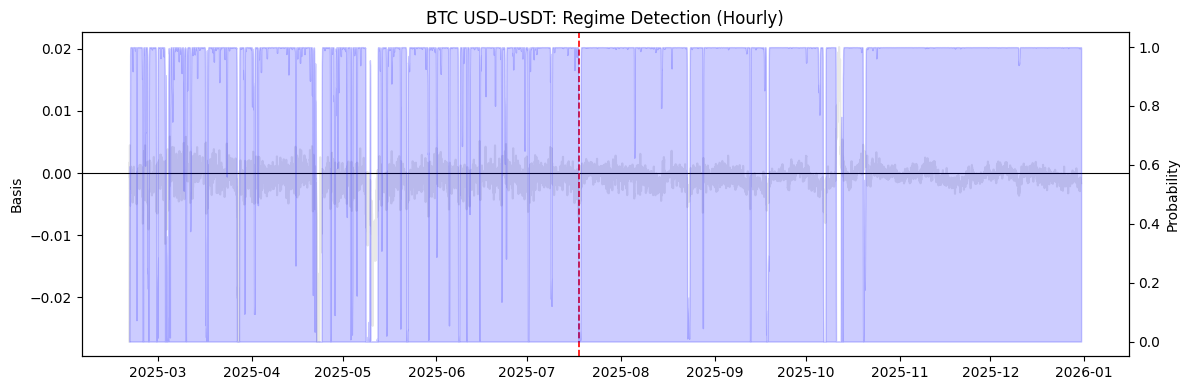


BTC USD–USDC (MS 2-regime)
  mean low-regime  = -5.330367e-03
  mean high-regime = -4.175224e-04
  Δμ (bps)         = 49.13
  avg P(high) pre  = 0.923
  avg P(high) post = 0.966


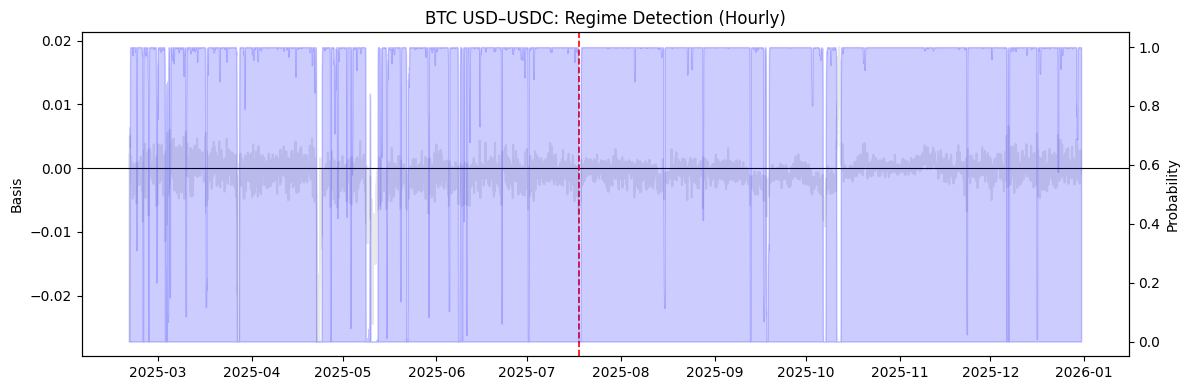


BTC USDT–USDC (MS 2-regime)
  mean low-regime  = -2.502248e-04
  mean high-regime = 3.881099e-04
  Δμ (bps)         = 6.38
  avg P(high) pre  = 0.222
  avg P(high) post = 0.596


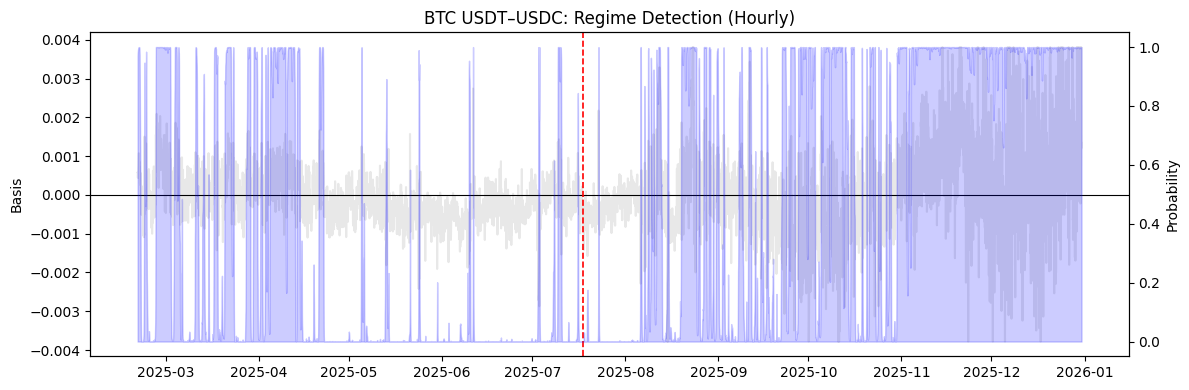

In [ ]:
EVENT = pd.Timestamp("2025-07-18 00:00:00", tz="UTC")

def ms_fit_report(series, name, event=EVENT):
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    y = y.sort_index()

    mu, sigma = y.mean(), y.std()
    y = y.clip(lower=mu - 4*sigma, upper=mu + 4*sigma)

    mod = MarkovRegression(
        y,
        k_regimes=2,
        trend="c",
        switching_variance=True
    )

    res = mod.fit(disp=False, maxiter=500, method='powell')

    p1 = res.smoothed_marginal_probabilities[1]
    reg1 = p1 > 0.5

    mu_reg0 = y[~reg1].mean()
    mu_reg1 = y[ reg1].mean()
    if mu_reg1 < mu_reg0:
        p1 = 1 - p1
        reg1 = p1 > 0.5
        mu_reg0 = y[~reg1].mean()
        mu_reg1 = y[ reg1].mean()

    dmu_bps = (mu_reg1 - mu_reg0) * 1e4
    p_pre  = p1.loc[p1.index <  event].mean()
    p_post = p1.loc[p1.index >= event].mean()

    print(f"\n{name} (MS 2-regime)")
    print(f"  mean low-regime  = {mu_reg0:.6e}")
    print(f"  mean high-regime = {mu_reg1:.6e}")
    print(f"  Δμ (bps)         = {dmu_bps:.2f}")
    print(f"  avg P(high) pre  = {p_pre:.3f}")
    print(f"  avg P(high) post = {p_post:.3f}")

    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(y.index, y, color='lightgray', alpha=0.5, label="Basis (Hourly)")
    ax1.axhline(0, color="black", lw=0.8)
    ax1.axvline(event, color="red", ls="--", lw=1.2, label="Event Date")
    ax1.set_ylabel("Basis")

    ax2 = ax1.twinx()
    ax2.fill_between(p1.index, 0, p1, color='blue', alpha=0.2, label="P(High Regime)")
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Probability")

    ax1.set_title(f"{name}: Regime Detection (Hourly)")
    fig.tight_layout()
    plt.show()

    return res, p1

res_usdusdt, p_usdusdt = ms_fit_report(df25_hourly["basis_BTC_USD_USDT"],  "BTC USD–USDT")
res_usdusdc, p_usdusdc = ms_fit_report(df25_hourly["basis_BTC_USD_USDC"],  "BTC USD–USDC")
res_usdtusdc, p_usdtusdc = ms_fit_report(df25_hourly["basis_BTC_USDT_USDC"], "BTC USDT–USDC")

In [ ]:
EVENT_2023 = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
POST_2023  = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")
EVENT_2025 = pd.Timestamp("2025-07-18 00:00:00", tz="UTC")

def regime_means(series, cuts):
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    out = {}
    for label, start, end in cuts:
        seg = y.loc[(y.index >= start) & (y.index < end)]
        out[label] = seg.mean()
    return out

cuts_2023 = [
    ("2023_pre",  pd.Timestamp("2023-03-01 00:00:00", tz="UTC"), EVENT_2023),
    ("2023_post", POST_2023, pd.Timestamp("2023-03-31 23:59:59", tz="UTC")),
]

cuts_2025 = [
    ("2025_pre",  pd.Timestamp("2025-01-01 00:00:00", tz="UTC"), EVENT_2025),
    ("2025_post", EVENT_2025, pd.Timestamp("2026-01-01 00:00:00", tz="UTC")),
]

df = df.sort_index()
df25 = df25.sort_index()

rows = []

# Pair 1: BTC USDT–USDC
m23 = regime_means(df["basis_BTC_USDT_USDC"], cuts_2023)
m25 = regime_means(df25["basis_BTC_USDT_USDC"], cuts_2025)
rows.append({"basis": "BTC USDT–USDC", **m23, **m25})

# Pair 2: BTC USD–USDT
m23 = regime_means(df["basis_BTC_USD_USDT"], cuts_2023)
m25 = regime_means(df25["basis_BTC_USD_USDT"], cuts_2025)
rows.append({"basis": "BTC USD–USDT", **m23, **m25})

# Pair 3: BTC USD–USDC
if "basis_BTC_USD_USDC" in df.columns and "basis_BTC_USD_USDC" in df25.columns:
    m23 = regime_means(df["basis_BTC_USD_USDC"], cuts_2023)
    m25 = regime_means(df25["basis_BTC_USD_USDC"], cuts_2025)
    rows.append({"basis": "BTC USD–USDC", **m23, **m25})

summary = pd.DataFrame(rows).set_index("basis") * 1e4

summary = summary.rename(columns={
    "2023_pre":  "2023 pre (Crisis)",
    "2023_post": "2023 post (Recovery)",
    "2025_pre":  "2025 pre (Baseline)",
    "2025_post": "2025 post (GENIUS)"
})

display(summary.round(2))

,2023 pre (Crisis),2023 post (Recovery),2025 pre (Baseline),2025 post (GENIUS)
basis,,,,
BTC USDT–USDC,-0.32,-33.87,-0.60,0.84
BTC USD–USDT,0.12,28.18,-11.46,-3.86
BTC USD–USDC,-0.20,-5.79,-12.06,-3.04


## Tests

2025 series range: 2025-02-19 13:00:00+00:00 → 2025-12-31 00:00:00+00:00
                            OLS Regression Results                            
Dep. Variable:     basis_BTC_USD_USDC   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     67.60
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.01e-16
Time:                        07:04:28   Log-Likelihood:             1.5564e+06
No. Observations:              452821   AIC:                        -3.113e+06
Df Residuals:                  452819   BIC:                        -3.113e+06
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

/tmp/ipython-input-2636734215.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real_beta = event_regression(y, real_event, lags=lags).params[1]
/tmp/ipython-input-2636734215.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = event_regression(y, fake, lags=lags).params[1]


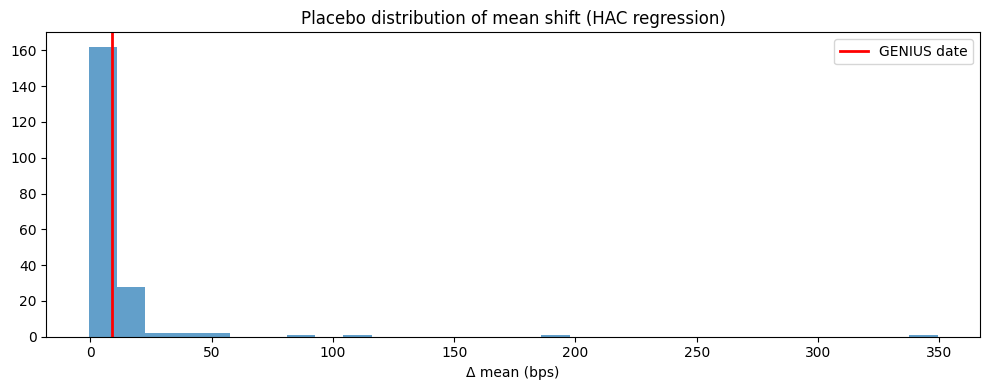

KS 2025: {'ok': True, 'pre_n': 213780, 'post_n': 239041, 'ks_stat': 0.09607767511157403, 'pvalue': 0.0}

2023 series range: 2023-03-01 00:00:00+00:00 → 2023-03-21 23:59:00+00:00
                             OLS Regression Results                            
Dep. Variable:     basis_BTC_USDT_USDC   R-squared:                       0.118
Model:                             OLS   Adj. R-squared:                  0.118
Method:                  Least Squares   F-statistic:                     89.82
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):           2.79e-21
Time:                         07:05:14   Log-Likelihood:                 82017.
No. Observations:                30240   AIC:                        -1.640e+05
Df Residuals:                    30238   BIC:                        -1.640e+05
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                 coef 

/tmp/ipython-input-2636734215.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real_beta = event_regression(y, real_event, lags=lags).params[1]
/tmp/ipython-input-2636734215.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = event_regression(y, fake, lags=lags).params[1]


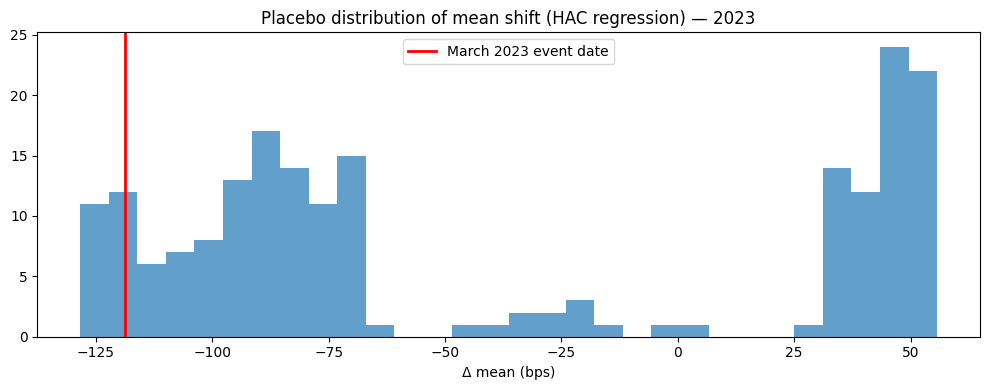

KS 2023: {'ok': True, 'pre_n': 12960, 'post_n': 17280, 'ks_stat': 0.8953317901234568, 'pvalue': 0.0}


In [ ]:
EVENT_2023 = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
POST_2023  = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")
EVENT_2025 = pd.Timestamp("2025-07-18 00:00:00", tz="UTC")

def clean_series(series):
    y = (series.replace([np.inf, -np.inf], np.nan)
              .dropna()
              .sort_index())
    if not isinstance(y.index, pd.DatetimeIndex):
        y.index = pd.to_datetime(y.index)
    return y

def assert_event_in_sample(y, event_date, name="series"):
    mn, mx = y.index.min(), y.index.max()
    if not (mn < event_date < mx):
        raise ValueError(
            f"{name}: event_date {event_date} not inside sample range "
            f"[{mn}, {mx}]. Choose an event within the data range or use the correct dataframe."
        )

def event_regression(series, event_date, lags=24):
    y = clean_series(series)
    assert_event_in_sample(y, event_date, name="event_regression series")

    D = (y.index >= event_date).astype(int)
    X = sm.add_constant(D)
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res

def placebo_distribution(series, real_event, n=200, lags=24, min_buffer=200, seed=123):
    """
    Pick random fake event dates inside sample (avoiding edges),
    compute the HAC event-regression beta for each fake date,
    compare to real beta.
    """
    rng = np.random.default_rng(seed)
    y = clean_series(series)
    assert_event_in_sample(y, real_event, name="placebo series")

    dates = y.index
    if len(dates) <= 2 * min_buffer + 1:
        raise ValueError("Series too short for placebo with the current min_buffer.")

    real_beta = event_regression(y, real_event, lags=lags).params[1]

    eligible = dates[min_buffer:-min_buffer]
    betas = []
    for _ in range(n):
        fake = eligible[int(rng.integers(0, len(eligible)))]
        beta = event_regression(y, fake, lags=lags).params[1]
        betas.append(beta)

    return real_beta, np.array(betas)

def ks_test_pre_post(series, event_date, min_n=50):
    """
    KS test on pre vs post distributions.
    Only runs if both samples have enough observations.
    """
    y = clean_series(series)
    assert_event_in_sample(y, event_date, name="KS series")

    pre = y.loc[y.index < event_date]
    post = y.loc[y.index >= event_date]

    if len(pre) < min_n or len(post) < min_n:
        return {
            "ok": False,
            "reason": f"Not enough data: pre={len(pre)}, post={len(post)} (need >= {min_n})"
        }

    res = ks_2samp(pre, post)
    return {
        "ok": True,
        "pre_n": len(pre),
        "post_n": len(post),
        "ks_stat": float(res.statistic),
        "pvalue": float(res.pvalue),
    }

# =========================
# 2) RUN 2025 GENIUS TESTS (use df25!)
# =========================
series25 = "basis_BTC_USD_USDC"
y25 = clean_series(df25[series25])

print("2025 series range:", y25.index.min(), "→", y25.index.max())
assert_event_in_sample(y25, EVENT_2025, name="df25 series")

# (A) HAC event regression
res25 = event_regression(y25, EVENT_2025, lags=24)
print(res25.summary())

# (B) Placebo distribution
real_beta25, placebo25 = placebo_distribution(y25, EVENT_2025, n=200, lags=24, min_buffer=200, seed=123)

plt.figure(figsize=(10,4))
plt.hist(placebo25 * 1e4, bins=30, alpha=0.7)
plt.axvline(real_beta25 * 1e4, color="red", lw=2, label="GENIUS date")
plt.xlabel("Δ mean (bps)")
plt.title("Placebo distribution of mean shift (HAC regression)")
plt.legend()
plt.tight_layout()
plt.show()

# (C) KS test (optional robustness)
ks25 = ks_test_pre_post(y25, EVENT_2025, min_n=50)
print("KS 2025:", ks25)

# =========================
# 3) RUN 2023 EVENT TESTS (use df or df23!)
# =========================
series23 = "basis_BTC_USDT_USDC"
y23 = clean_series(df[series23])

print("\n2023 series range:", y23.index.min(), "→", y23.index.max())
assert_event_in_sample(y23, EVENT_2023, name="df (2023) series")

res23 = event_regression(y23, EVENT_2023, lags=60)  # higher lags OK for minute data
print(res23.summary())

real_beta23, placebo23 = placebo_distribution(y23, EVENT_2023, n=200, lags=60, min_buffer=500, seed=123)

plt.figure(figsize=(10,4))
plt.hist(placebo23 * 1e4, bins=30, alpha=0.7)
plt.axvline(real_beta23 * 1e4, color="red", lw=2, label="March 2023 event date")
plt.xlabel("Δ mean (bps)")
plt.title("Placebo distribution of mean shift (HAC regression) — 2023")
plt.legend()
plt.tight_layout()
plt.show()

ks23 = ks_test_pre_post(y23, EVENT_2023, min_n=500)  # minute data → set bigger min_n
print("KS 2023:", ks23)


In [ ]:
EVENT_2023 = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
POST_2023  = pd.Timestamp("2023-03-14 00:00:00", tz="UTC")
EVENT_2025 = pd.Timestamp("2025-07-18 00:00:00", tz="UTC")

def regime_means(series, cuts):
    """
    series: pd.Series with datetime index
    cuts: list of (label, start, end)
    returns: dict label -> mean(series in that window)
    """
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    out = {}
    for label, start, end in cuts:
        seg = y.loc[(y.index >= start) & (y.index < end)]
        out[label] = seg.mean()
    return out

cuts_2023 = [
    ("2023_pre",  pd.Timestamp("2023-03-01 00:00:00", tz="UTC"), EVENT_2023),
    ("2023_post", POST_2023, pd.Timestamp("2023-03-31 23:59:59", tz="UTC")),
]

cuts_2025 = [
    ("2025_pre",  pd.Timestamp("2025-01-01 00:00:00", tz="UTC"), EVENT_2025),
    ("2025_post", EVENT_2025, pd.Timestamp("2026-01-01 00:00:00", tz="UTC")),
]

rows = []
basis_pairs = ["basis_BTC_USDT_USDC", "basis_BTC_USD_USDT", "basis_BTC_USD_USDC"]

for bp in basis_pairs:
    if bp in df.columns and bp in df25.columns:
        m23 = regime_means(df[bp], cuts_2023)
        m25 = regime_means(df25[bp], cuts_2025)
        rows.append({"basis": bp.replace("basis_", "").replace("_", " "), **m23, **m25})

summary = pd.DataFrame(rows).set_index("basis") * 1e4

summary = summary.rename(columns={
    "2023_pre":  "2023 pre (Crisis)",
    "2023_post": "2023 post (Recovery)",
    "2025_pre":  "2025 pre (Baseline)",
    "2025_post": "2025 post (GENIUS)"
})

print("SPREAD MEANS ACROSS REGIMES (in bps)")
display(summary.round(2))

SPREAD MEANS ACROSS REGIMES (in bps)


,2023 pre (Crisis),2023 post (Recovery),2025 pre (Baseline),2025 post (GENIUS)
basis,,,,
BTC USDT USDC,-0.32,-33.87,-0.60,0.84
BTC USD USDT,0.12,28.18,-11.46,-3.86
BTC USD USDC,-0.20,-5.79,-12.06,-3.04



--- 2025 REGRESSION SUMMARY: basis_BTC_USD_USDC ---
                            OLS Regression Results                            
Dep. Variable:     basis_BTC_USD_USDC   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     67.60
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.01e-16
Time:                        07:05:28   Log-Likelihood:             1.5564e+06
No. Observations:              452821   AIC:                        -3.113e+06
Df Residuals:                  452819   BIC:                        -3.113e+06
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/tmp/ipython-input-899155170.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas.append(event_regression(y25, fake_date).params[1])
/tmp/ipython-input-899155170.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real_beta = res25.params[1]


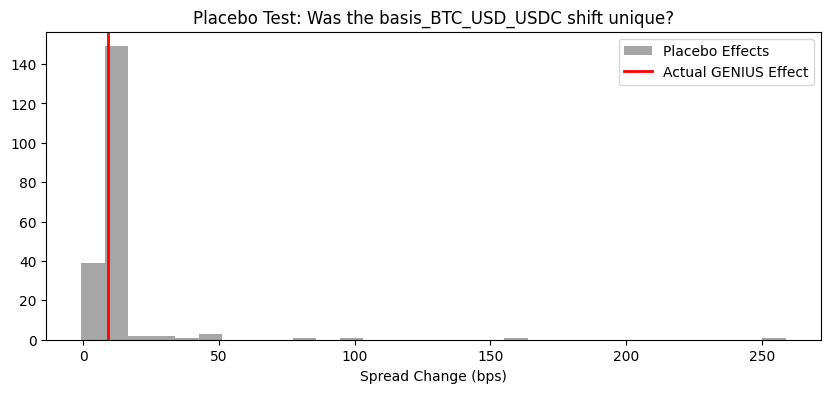

KS Test p-value: 0.00000 (Significant if < 0.05)


In [ ]:
def clean_series(series):
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().sort_index()
    return y

def event_regression(series, event_date, lags=24):
    y = clean_series(series)
    # Define Dummy D: 0 before event, 1 after
    D = (y.index >= event_date).astype(int)
    X = sm.add_constant(D)
    # Use HAC (Heteroskedasticity and Autocorrelation Consistent) errors
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res

def run_analysis_2025(series_name):
    y25 = clean_series(df25[series_name])

    # A) HAC Event Regression
    res25 = event_regression(y25, EVENT_2025, lags=24)
    print(f"\n--- 2025 REGRESSION SUMMARY: {series_name} ---")
    print(res25.summary())

    # B) Placebo Distribution
    rng = np.random.default_rng(123)
    eligible_dates = y25.index[500:-500]
    betas = []

    print("Running placebos...")
    for _ in range(200):
        fake_date = eligible_dates[rng.integers(0, len(eligible_dates))]
        betas.append(event_regression(y25, fake_date).params[1])

    real_beta = res25.params[1]

    # C) Visual Plot
    plt.figure(figsize=(10,4))
    plt.hist(np.array(betas) * 1e4, bins=30, alpha=0.7, color='gray', label='Placebo Effects')
    plt.axvline(real_beta * 1e4, color="red", lw=2, label="Actual GENIUS Effect")
    plt.xlabel("Spread Change (bps)")
    plt.title(f"Placebo Test: Was the {series_name} shift unique?")
    plt.legend()
    plt.show()

    # D) KS Test (Distribution shift)
    pre = y25.loc[y25.index < EVENT_2025]
    post = y25.loc[y25.index >= EVENT_2025]
    ks_stat, p_val = ks_2samp(pre, post)
    print(f"KS Test p-value: {p_val:.5f} (Significant if < 0.05)")

run_analysis_2025("basis_BTC_USD_USDC")